<a href="https://www.kaggle.com/code/jf10101001/group04-bloodmnist-task2-proposed-model?scriptVersionId=342328604" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#**CSE475 - Section 02**

- - -

**Group Information - Group 04 (BloodMNIST)**

* Nishat Subha Mithela (2023-1-60-248) - EDA

* Nusrat Jahan (2022-2-60-128) - Baselines

* Humayara Nahar Moumita (2021-2-60-121) - CNN + Attention

* Fahmida Jannat (2025-1-60-334) - GNN





- - -


**Course Instructor**

Dr. Raihan Ul Islam

Associate Professor

Department of Computer Science & Engineering

East West University

#Dataset Load

In [1]:
# =========================================================
# DATASET LOAD
# =========================================================

# Install only the packages required for loading the dataset
%pip -q install -U kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 8.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# =========================================================
# 1. Imports and reproducibility
# =========================================================

from pathlib import Path
import random

import kagglehub
import numpy as np
import tensorflow as tf


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# =========================================================
# 2. Download BloodMNIST
# =========================================================

DATA_DIR = Path(
    kagglehub.dataset_download(
        "subbhaa/bloodmnist-medmnist-dataset"
    )
)

print("Dataset directory:", DATA_DIR)

Dataset directory: /kaggle/input/datasets/subbhaa/bloodmnist-medmnist-dataset


In [4]:
# =========================================================
# 3. Find and load the BloodMNIST NPZ file
# =========================================================

npz_files = sorted(
    DATA_DIR.rglob("*.npz")
)

assert npz_files, (
    "No NPZ dataset file was found."
)

NPZ_PATH = next(
    (
        path
        for path in npz_files
        if path.name.lower() == "bloodmnist.npz"
    ),
    npz_files[0]
)

with np.load(
    NPZ_PATH,
    allow_pickle=False
) as data:

    required_arrays = [
        "train_images",
        "train_labels",
        "val_images",
        "val_labels",
        "test_images",
        "test_labels"
    ]

    missing_arrays = [
        name
        for name in required_arrays
        if name not in data.files
    ]

    assert not missing_arrays, (
        f"Missing arrays: {missing_arrays}"
    )

    # Copy arrays so they remain available after closing NPZ
    X_train = data["train_images"].copy()
    y_train = data["train_labels"].reshape(-1).copy()

    X_val = data["val_images"].copy()
    y_val = data["val_labels"].reshape(-1).copy()

    X_test = data["test_images"].copy()
    y_test = data["test_labels"].reshape(-1).copy()


# Ensure correct label data type
y_train = y_train.astype(np.int32)
y_val = y_val.astype(np.int32)
y_test = y_test.astype(np.int32)


print("Loaded:", NPZ_PATH.name)

Loaded: bloodmnist.npz


In [5]:
# =========================================================
# 4. Class information
# =========================================================

CLASS_NAMES = {
    0: "Basophil",
    1: "Eosinophil",
    2: "Erythroblast",
    3: "Immature granulocytes",
    4: "Lymphocyte",
    5: "Monocyte",
    6: "Neutrophil",
    7: "Platelet"
}

class_names = [
    CLASS_NAMES[class_id]
    for class_id in sorted(CLASS_NAMES)
]

NUM_CLASSES = len(class_names)

In [6]:
# =========================================================
# 5. Validate the loaded dataset
# =========================================================

raw_splits = {
    "Train": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}

for split_name, (images, labels) in raw_splits.items():

    assert isinstance(images, np.ndarray), (
        f"{split_name}: images must be a NumPy array."
    )

    assert isinstance(labels, np.ndarray), (
        f"{split_name}: labels must be a NumPy array."
    )

    assert images.ndim == 4, (
        f"{split_name}: expected image shape "
        f"(samples, height, width, channels), "
        f"but received {images.shape}."
    )

    assert labels.ndim == 1, (
        f"{split_name}: labels must be one-dimensional."
    )

    assert len(images) == len(labels), (
        f"{split_name}: number of images and labels differs."
    )

    assert labels.min() >= 0, (
        f"{split_name}: negative class label detected."
    )

    assert labels.max() < NUM_CLASSES, (
        f"{split_name}: invalid class label detected."
    )


print("Dataset loading and validation completed.")
print("-" * 60)

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Validation images:", X_val.shape)
print("Validation labels:", y_val.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

print("\nClasses:", NUM_CLASSES)
print("Class names:", class_names)

Dataset loading and validation completed.
------------------------------------------------------------
Training images: (11959, 28, 28, 3)
Training labels: (11959,)
Validation images: (1712, 28, 28, 3)
Validation labels: (1712,)
Test images: (3421, 28, 28, 3)
Test labels: (3421,)

Classes: 8
Class names: ['Basophil', 'Eosinophil', 'Erythroblast', 'Immature granulocytes', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']


#Dataset EDA

In [7]:
# =========================================================
# OPTIONAL EXPLORATORY DATA ANALYSIS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# =========================================================
# 1. Verify that the Dataset Load section was executed
# =========================================================

eda_required_variables = [
    "X_train",
    "y_train",
    "X_val",
    "y_val",
    "X_test",
    "y_test",
    "CLASS_NAMES"
]

eda_missing_variables = [
    variable_name
    for variable_name in eda_required_variables
    if variable_name not in globals()
]

if eda_missing_variables:
    raise RuntimeError(
        "Run the Dataset Load section before running EDA. "
        f"Missing variables: {eda_missing_variables}"
    )


# Create class information locally for EDA
if isinstance(CLASS_NAMES, dict):
    eda_class_names = [
        CLASS_NAMES[class_id]
        for class_id in sorted(CLASS_NAMES)
    ]
else:
    eda_class_names = list(CLASS_NAMES)

eda_num_classes = len(eda_class_names)


# Local split dictionary used only by EDA
eda_splits = {
    "Train": (
        np.asarray(X_train),
        np.asarray(y_train).reshape(-1)
    ),
    "Validation": (
        np.asarray(X_val),
        np.asarray(y_val).reshape(-1)
    ),
    "Test": (
        np.asarray(X_test),
        np.asarray(y_test).reshape(-1)
    )
}


print("EDA dependencies are ready.")
print("Number of classes:", eda_num_classes)
print("Class names:", eda_class_names)

EDA dependencies are ready.
Number of classes: 8
Class names: ['Basophil', 'Eosinophil', 'Erythroblast', 'Immature granulocytes', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']


In [8]:
# =========================================================
# 2. Dataset structure summary
# =========================================================

eda_structure_rows = []

for split_name, (images, labels) in eda_splits.items():

    eda_structure_rows.append({
        "Split": split_name,
        "Number of Images": len(images),
        "Image Shape": str(images.shape[1:]),
        "Images Dtype": str(images.dtype),
        "Labels Shape": str(labels.shape),
        "Labels Dtype": str(labels.dtype),
        "Minimum Label": int(labels.min()),
        "Maximum Label": int(labels.max())
    })


eda_structure_df = pd.DataFrame(
    eda_structure_rows
)

print("Dataset structure")
display(eda_structure_df)

Dataset structure


,Split,Number of Images,Image Shape,Images Dtype,Labels Shape,Labels Dtype,Minimum Label,Maximum Label
0,Train,11959,"(28, 28, 3)",uint8,"(11959,)",int32,0,7
1,Validation,1712,"(28, 28, 3)",uint8,"(1712,)",int32,0,7
2,Test,3421,"(28, 28, 3)",uint8,"(3421,)",int32,0,7


In [9]:
# =========================================================
# 3. Dataset split sizes
# =========================================================

eda_split_sizes = {
    split_name: len(images)
    for split_name, (images, _) in eda_splits.items()
}

eda_total_samples = sum(
    eda_split_sizes.values()
)

eda_split_df = pd.DataFrame({
    "Split": list(eda_split_sizes.keys()),
    "Samples": list(eda_split_sizes.values())
})

eda_split_df["Percentage"] = (
    eda_split_df["Samples"]
    / eda_total_samples
    * 100
)

print("Dataset split summary")
display(eda_split_df)

Dataset split summary


,Split,Samples,Percentage
0,Train,11959,69.968406
1,Validation,1712,10.016382
2,Test,3421,20.015212


In [10]:
# =========================================================
# 4. Class distribution for each split
# =========================================================

eda_distribution_rows = []

for split_name, (_, labels) in eda_splits.items():

    split_counts = np.bincount(
        labels.astype(np.int32),
        minlength=eda_num_classes
    )

    split_total = len(labels)

    for class_id in range(eda_num_classes):

        eda_distribution_rows.append({
            "Split": split_name,
            "Class ID": class_id,
            "Class Name": eda_class_names[class_id],
            "Count": int(split_counts[class_id]),
            "Percentage": (
                split_counts[class_id]
                / split_total
                * 100
            )
        })


eda_distribution_df = pd.DataFrame(
    eda_distribution_rows
)

print("Class distribution across all splits")
display(eda_distribution_df)

Class distribution across all splits


,Split,Class ID,Class Name,Count,Percentage
0,Train,0,Basophil,852,7.124342
1,Train,1,Eosinophil,2181,18.237311
2,Train,2,Erythroblast,1085,9.072665
3,Train,3,Immature granulocytes,2026,16.941216
4,Train,4,Lymphocyte,849,7.099256
5,Train,5,Monocyte,993,8.303370
6,Train,6,Neutrophil,2330,19.483234
7,Train,7,Platelet,1643,13.738607
8,Validation,0,Basophil,122,7.126168
9,Validation,1,Eosinophil,312,18.224299


In [11]:
# =========================================================
# 5. Class-count comparison table
# =========================================================

eda_class_count_table = (
    eda_distribution_df
    .pivot(
        index=[
            "Class ID",
            "Class Name"
        ],
        columns="Split",
        values="Count"
    )
    .reset_index()
)

eda_class_count_table.columns.name = None

expected_columns = [
    "Class ID",
    "Class Name",
    "Train",
    "Validation",
    "Test"
]

eda_class_count_table = eda_class_count_table[
    expected_columns
]

eda_class_count_table["Total"] = (
    eda_class_count_table["Train"]
    + eda_class_count_table["Validation"]
    + eda_class_count_table["Test"]
)

print("Class-count comparison")
display(eda_class_count_table)

Class-count comparison


,Class ID,Class Name,Train,Validation,Test,Total
0,0,Basophil,852,122,244,1218
1,1,Eosinophil,2181,312,624,3117
2,2,Erythroblast,1085,155,311,1551
3,3,Immature granulocytes,2026,290,579,2895
4,4,Lymphocyte,849,122,243,1214
5,5,Monocyte,993,143,284,1420
6,6,Neutrophil,2330,333,666,3329
7,7,Platelet,1643,235,470,2348


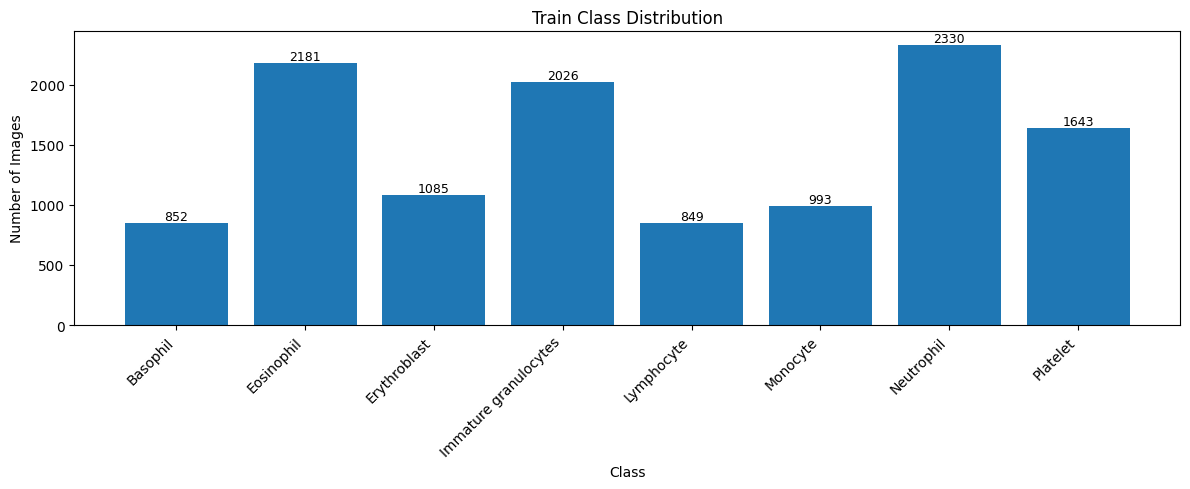

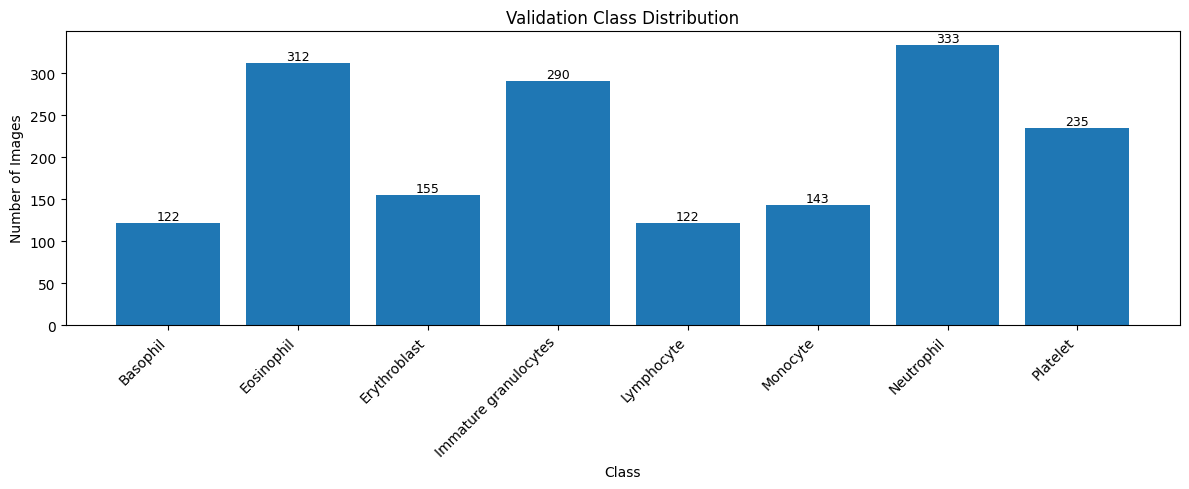

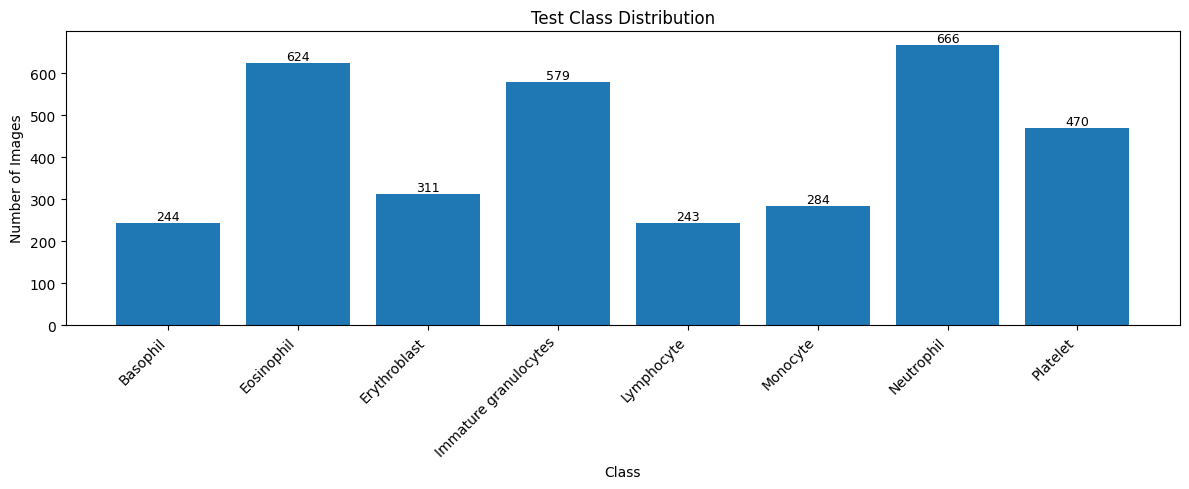

In [12]:
# =========================================================
# 6. Plot class distribution for each split
# =========================================================

for split_name, (_, labels) in eda_splits.items():

    split_counts = np.bincount(
        labels.astype(np.int32),
        minlength=eda_num_classes
    )

    plt.figure(figsize=(12, 5))

    plt.bar(
        eda_class_names,
        split_counts
    )

    plt.title(
        f"{split_name} Class Distribution"
    )

    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(
        rotation=45,
        ha="right"
    )

    for index, count in enumerate(split_counts):
        plt.text(
            index,
            count,
            str(int(count)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

In [13]:
# =========================================================
# 7. Training-class imbalance analysis
# =========================================================

eda_train_counts = np.bincount(
    np.asarray(y_train).reshape(-1).astype(np.int32),
    minlength=eda_num_classes
)

eda_min_class_id = int(
    np.argmin(eda_train_counts)
)

eda_max_class_id = int(
    np.argmax(eda_train_counts)
)

eda_min_count = int(
    eda_train_counts[eda_min_class_id]
)

eda_max_count = int(
    eda_train_counts[eda_max_class_id]
)

eda_imbalance_ratio = (
    eda_max_count / eda_min_count
)


eda_imbalance_df = pd.DataFrame({
    "Class ID": np.arange(eda_num_classes),
    "Class Name": eda_class_names,
    "Training Count": eda_train_counts,
    "Difference from Minimum": (
        eda_train_counts - eda_min_count
    ),
    "Ratio to Minimum": (
        eda_train_counts / eda_min_count
    )
})

print("Training imbalance analysis")
display(eda_imbalance_df)


print("\nTraining imbalance summary")
print("-" * 60)

print(
    f"Smallest class: "
    f"{eda_class_names[eda_min_class_id]} "
    f"({eda_min_count} samples)"
)

print(
    f"Largest class: "
    f"{eda_class_names[eda_max_class_id]} "
    f"({eda_max_count} samples)"
)

print(
    f"Maximum-to-minimum ratio: "
    f"{eda_imbalance_ratio:.3f}:1"
)

Training imbalance analysis


,Class ID,Class Name,Training Count,Difference from Minimum,Ratio to Minimum
0,0,Basophil,852,3,1.003534
1,1,Eosinophil,2181,1332,2.568905
2,2,Erythroblast,1085,236,1.277974
3,3,Immature granulocytes,2026,1177,2.386337
4,4,Lymphocyte,849,0,1.000000
5,5,Monocyte,993,144,1.169611
6,6,Neutrophil,2330,1481,2.744405
7,7,Platelet,1643,794,1.935218



Training imbalance summary
------------------------------------------------------------
Smallest class: Lymphocyte (849 samples)
Largest class: Neutrophil (2330 samples)
Maximum-to-minimum ratio: 2.744:1


In [14]:
# =========================================================
# 8. Image-value statistics
# =========================================================

eda_pixel_statistics = []

for split_name, (images, _) in eda_splits.items():

    images_float = images.astype(
        np.float32,
        copy=False
    )

    eda_pixel_statistics.append({
        "Split": split_name,
        "Minimum Pixel": float(
            np.min(images_float)
        ),
        "Maximum Pixel": float(
            np.max(images_float)
        ),
        "Mean Pixel": float(
            np.mean(images_float)
        ),
        "Standard Deviation": float(
            np.std(images_float)
        )
    })


eda_pixel_stats_df = pd.DataFrame(
    eda_pixel_statistics
)

print("Pixel-value statistics")
display(eda_pixel_stats_df)

Pixel-value statistics


,Split,Minimum Pixel,Maximum Pixel,Mean Pixel,Standard Deviation
0,Train,0.0,255.0,182.766785,52.769131
1,Validation,0.0,255.0,182.801636,52.533981
2,Test,0.0,255.0,182.699188,52.818863


In [15]:
# =========================================================
# 9. Per-channel RGB statistics
# =========================================================

eda_channel_names = [
    "Red",
    "Green",
    "Blue"
]

eda_channel_rows = []

for split_name, (images, _) in eda_splits.items():

    if images.ndim != 4:
        continue

    number_of_channels = images.shape[-1]

    for channel_index in range(number_of_channels):

        channel_values = images[
            ...,
            channel_index
        ].astype(
            np.float32,
            copy=False
        )

        channel_name = (
            eda_channel_names[channel_index]
            if channel_index < len(eda_channel_names)
            else f"Channel {channel_index}"
        )

        eda_channel_rows.append({
            "Split": split_name,
            "Channel": channel_name,
            "Mean": float(
                np.mean(channel_values)
            ),
            "Standard Deviation": float(
                np.std(channel_values)
            ),
            "Minimum": float(
                np.min(channel_values)
            ),
            "Maximum": float(
                np.max(channel_values)
            )
        })


eda_channel_stats_df = pd.DataFrame(
    eda_channel_rows
)

print("Per-channel image statistics")
display(eda_channel_stats_df)

Per-channel image statistics


,Split,Channel,Mean,Standard Deviation,Minimum,Maximum
0,Train,Red,202.558777,54.985760,9.0,255.0
1,Train,Green,168.212997,61.608868,0.0,255.0
2,Train,Blue,177.528915,30.061691,32.0,255.0
3,Validation,Red,202.571548,54.694283,17.0,255.0
4,Validation,Green,168.269073,61.321899,0.0,255.0
5,Validation,Blue,177.564240,29.969042,27.0,255.0
6,Test,Red,202.485245,55.033085,12.0,255.0
7,Test,Green,168.130692,61.668407,0.0,253.0
8,Test,Blue,177.481689,30.114925,18.0,255.0


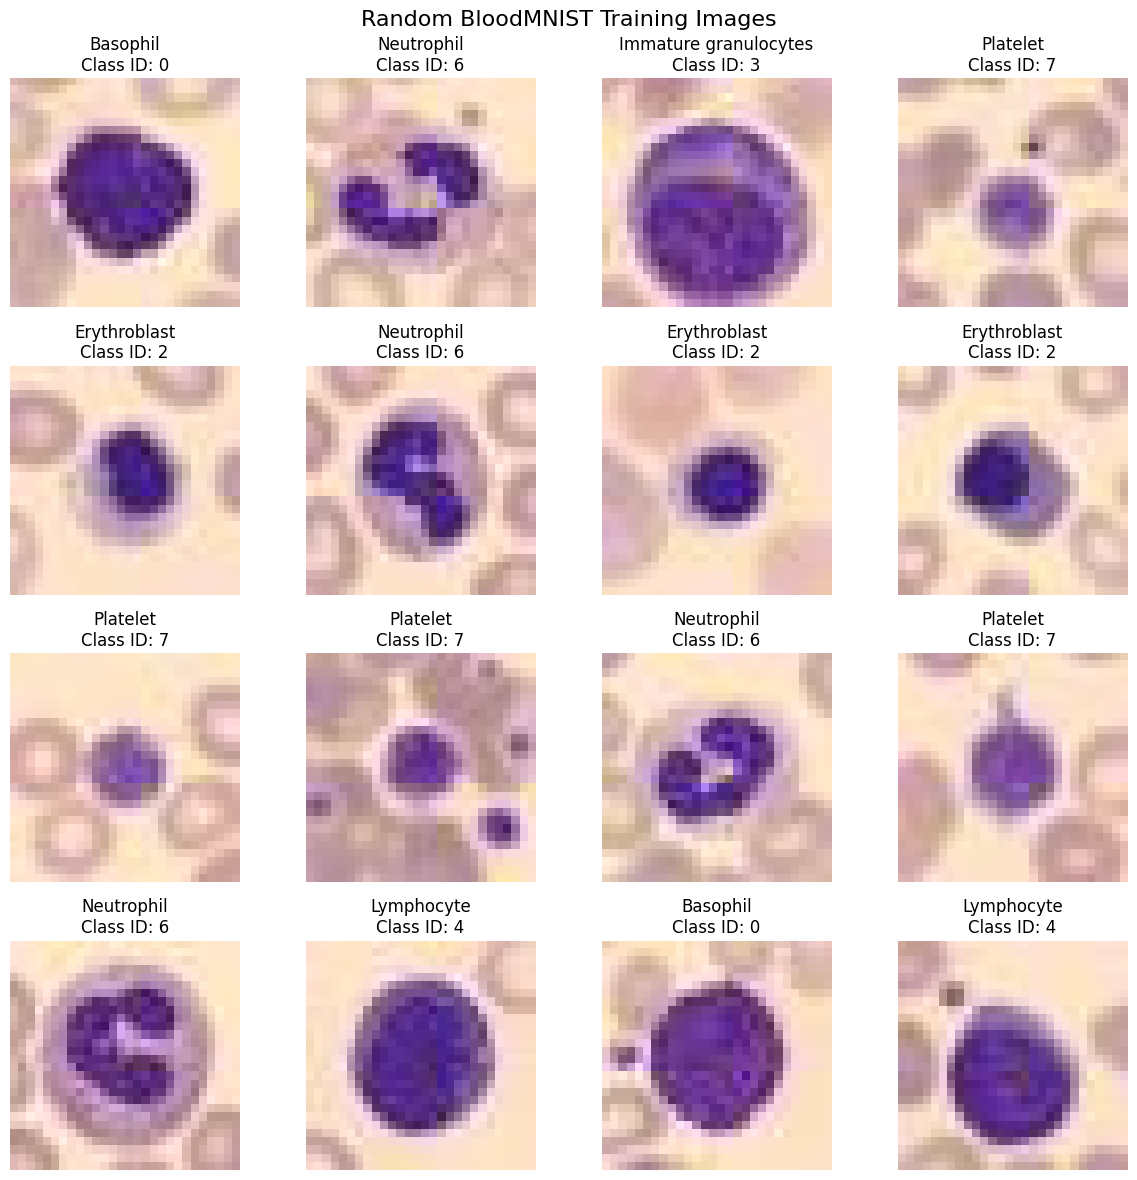

In [16]:
# =========================================================
# 10. Random training samples
# =========================================================

EDA_RANDOM_SEED = 42
EDA_NUMBER_OF_SAMPLES = 16

eda_rng = np.random.default_rng(
    EDA_RANDOM_SEED
)

eda_sample_count = min(
    EDA_NUMBER_OF_SAMPLES,
    len(X_train)
)

eda_random_indices = eda_rng.choice(
    len(X_train),
    size=eda_sample_count,
    replace=False
)


eda_columns = 4
eda_rows = int(
    np.ceil(
        eda_sample_count / eda_columns
    )
)

plt.figure(
    figsize=(12, 3 * eda_rows)
)

for plot_position, sample_index in enumerate(
    eda_random_indices,
    start=1
):

    image = X_train[sample_index]
    label_id = int(y_train[sample_index])

    plt.subplot(
        eda_rows,
        eda_columns,
        plot_position
    )

    plt.imshow(image)

    plt.title(
        f"{eda_class_names[label_id]}\n"
        f"Class ID: {label_id}"
    )

    plt.axis("off")


plt.suptitle(
    "Random BloodMNIST Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

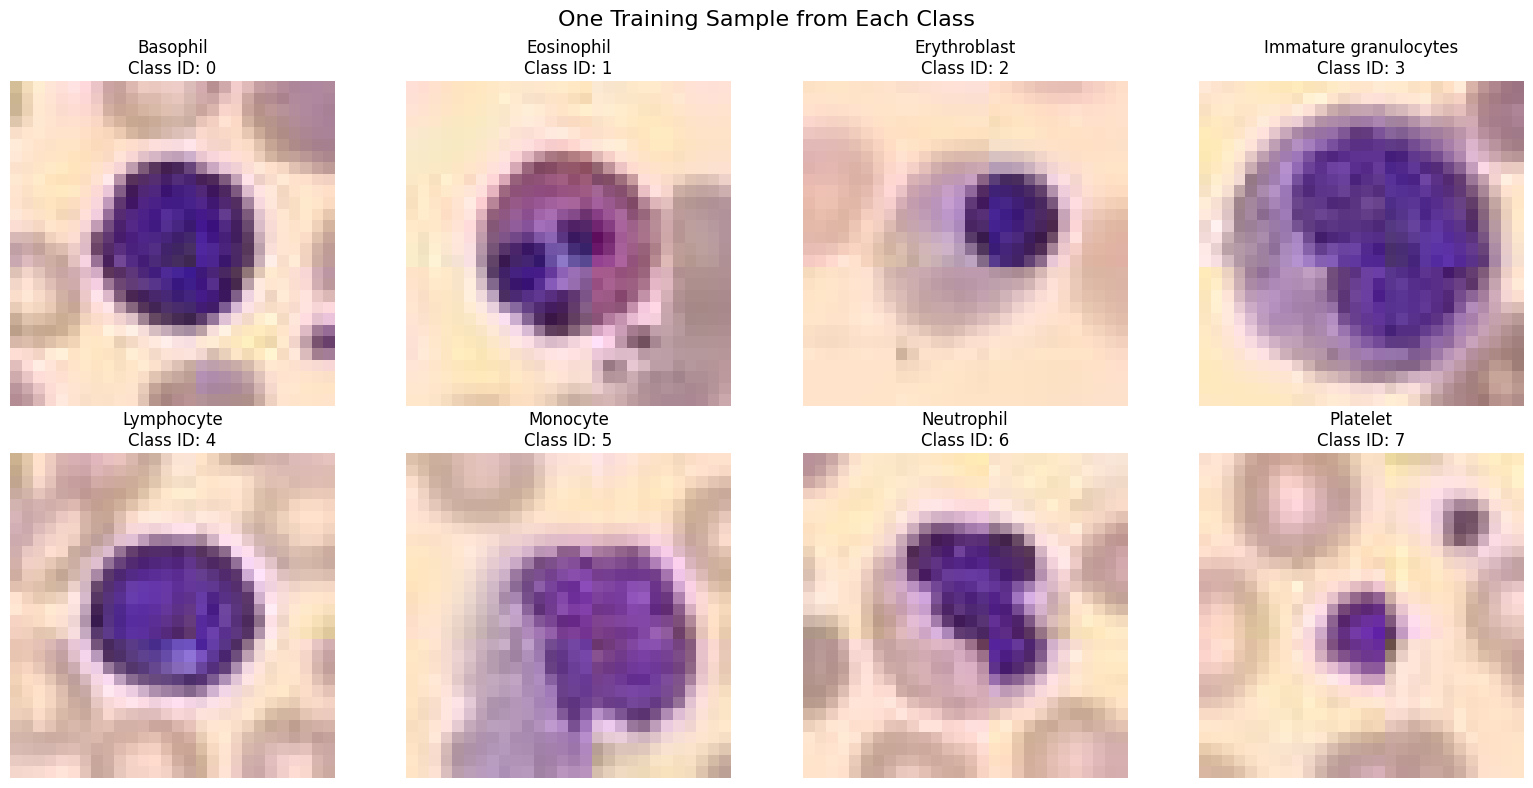

In [17]:
# =========================================================
# 11. One training image from each class
# =========================================================

plt.figure(
    figsize=(16, 8)
)

for class_id in range(eda_num_classes):

    class_indices = np.flatnonzero(
        np.asarray(y_train).reshape(-1)
        == class_id
    )

    if len(class_indices) == 0:
        continue

    sample_index = class_indices[0]

    plt.subplot(
        2,
        4,
        class_id + 1
    )

    plt.imshow(
        X_train[sample_index]
    )

    plt.title(
        f"{eda_class_names[class_id]}\n"
        f"Class ID: {class_id}"
    )

    plt.axis("off")


plt.suptitle(
    "One Training Sample from Each Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

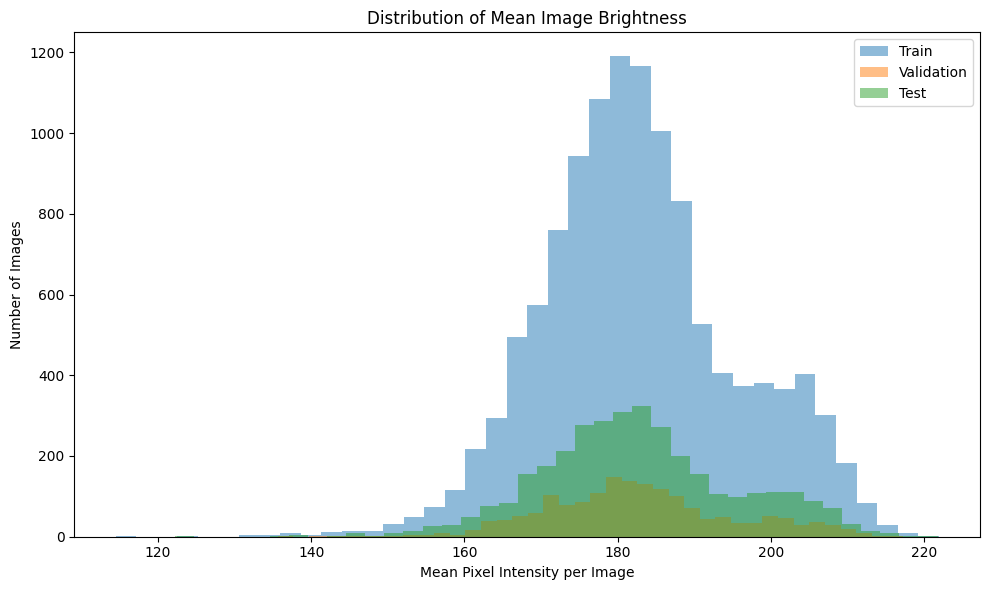

In [18]:
# =========================================================
# 13. Mean image brightness by split
# =========================================================

plt.figure(
    figsize=(10, 6)
)

for split_name, (images, _) in eda_splits.items():

    image_brightness = np.mean(
        images.astype(
            np.float32,
            copy=False
        ),
        axis=(1, 2, 3)
    )

    plt.hist(
        image_brightness,
        bins=40,
        alpha=0.5,
        label=split_name
    )


plt.title(
    "Distribution of Mean Image Brightness"
)

plt.xlabel(
    "Mean Pixel Intensity per Image"
)

plt.ylabel(
    "Number of Images"
)

plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# =========================================================
# 14. Mean image brightness by training class
# =========================================================

eda_train_images_float = X_train.astype(
    np.float32,
    copy=False
)

eda_train_brightness = np.mean(
    eda_train_images_float,
    axis=(1, 2, 3)
)

eda_brightness_rows = []

for class_id in range(eda_num_classes):

    class_mask = (
        np.asarray(y_train).reshape(-1)
        == class_id
    )

    class_brightness = eda_train_brightness[
        class_mask
    ]

    eda_brightness_rows.append({
        "Class ID": class_id,
        "Class Name": eda_class_names[class_id],
        "Mean Brightness": float(
            np.mean(class_brightness)
        ),
        "Brightness Std": float(
            np.std(class_brightness)
        ),
        "Minimum Brightness": float(
            np.min(class_brightness)
        ),
        "Maximum Brightness": float(
            np.max(class_brightness)
        )
    })


eda_brightness_df = pd.DataFrame(
    eda_brightness_rows
)

print("Training-image brightness by class")
display(eda_brightness_df)

Training-image brightness by class


,Class ID,Class Name,Mean Brightness,Brightness Std,Minimum Brightness,Maximum Brightness
0,0,Basophil,174.284592,7.498600,146.994049,193.666672
1,1,Eosinophil,178.277847,6.369565,144.018707,203.796768
2,2,Erythroblast,192.171371,8.731337,157.197708,212.867767
3,3,Immature granulocytes,172.935608,10.742258,114.488518,198.031891
4,4,Lymphocyte,185.602615,6.088991,155.406464,203.502975
5,5,Monocyte,170.517624,6.685088,141.491928,190.971085
6,6,Neutrophil,183.767700,6.474683,153.271683,200.134354
7,7,Platelet,203.556091,5.612568,174.414108,221.879684


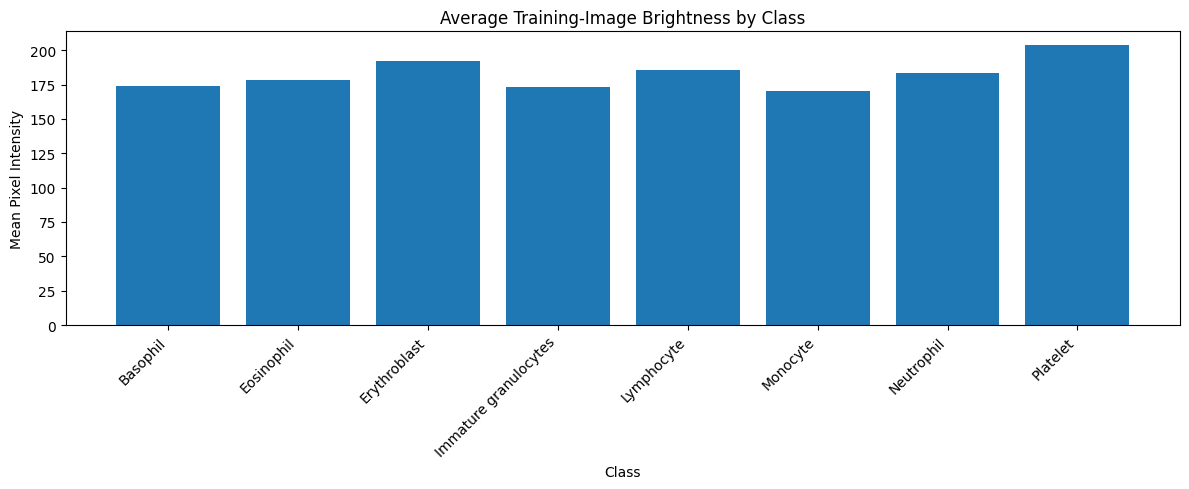

In [20]:
plt.figure(
    figsize=(12, 5)
)

plt.bar(
    eda_brightness_df["Class Name"],
    eda_brightness_df["Mean Brightness"]
)

plt.title(
    "Average Training-Image Brightness by Class"
)

plt.xlabel("Class")
plt.ylabel("Mean Pixel Intensity")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [21]:
# =========================================================
# 15. Mean RGB values by training class
# =========================================================

eda_rgb_rows = []

for class_id in range(eda_num_classes):

    class_images = X_train[
        np.asarray(y_train).reshape(-1)
        == class_id
    ].astype(
        np.float32,
        copy=False
    )

    channel_means = np.mean(
        class_images,
        axis=(0, 1, 2)
    )

    eda_rgb_rows.append({
        "Class ID": class_id,
        "Class Name": eda_class_names[class_id],
        "Red Mean": float(channel_means[0]),
        "Green Mean": float(channel_means[1]),
        "Blue Mean": float(channel_means[2])
    })


eda_rgb_df = pd.DataFrame(
    eda_rgb_rows
)

print("Mean RGB values by training class")
display(eda_rgb_df)

Mean RGB values by training class


,Class ID,Class Name,Red Mean,Green Mean,Blue Mean
0,0,Basophil,192.736313,156.669693,173.592896
1,1,Eosinophil,200.678497,160.998230,173.418060
2,2,Erythroblast,212.625641,182.372818,181.767166
3,3,Immature granulocytes,189.540024,154.641327,174.824631
4,4,Lymphocyte,205.188126,173.236755,178.570129
5,5,Monocyte,185.601288,150.764740,175.306488
6,6,Neutrophil,204.388672,169.310593,177.667755
7,7,Platelet,228.685425,196.365768,185.901245


In [22]:
# =========================================================
# 16. Data-integrity checks
# =========================================================

eda_integrity_rows = []

for split_name, (images, labels) in eda_splits.items():

    invalid_low_labels = int(
        np.sum(labels < 0)
    )

    invalid_high_labels = int(
        np.sum(labels >= eda_num_classes)
    )

    nan_image_values = int(
        np.isnan(
            images.astype(
                np.float32,
                copy=False
            )
        ).sum()
    )

    infinite_image_values = int(
        np.isinf(
            images.astype(
                np.float32,
                copy=False
            )
        ).sum()
    )

    eda_integrity_rows.append({
        "Split": split_name,
        "Invalid Negative Labels": invalid_low_labels,
        "Labels Above Class Range": invalid_high_labels,
        "NaN Pixel Values": nan_image_values,
        "Infinite Pixel Values": infinite_image_values
    })


eda_integrity_df = pd.DataFrame(
    eda_integrity_rows
)

print("Data-integrity checks")
display(eda_integrity_df)

Data-integrity checks


,Split,Invalid Negative Labels,Labels Above Class Range,NaN Pixel Values,Infinite Pixel Values
0,Train,0,0,0,0
1,Validation,0,0,0,0
2,Test,0,0,0,0


In [23]:
# =========================================================
# 17. Exact duplicates within each split
# =========================================================

import hashlib


def eda_image_hash(image):
    """
    Generate a deterministic hash for one image.
    """

    contiguous_image = np.ascontiguousarray(
        image
    )

    return hashlib.sha256(
        contiguous_image.tobytes()
    ).hexdigest()


eda_duplicate_rows = []

for split_name, (images, _) in eda_splits.items():

    split_hashes = [
        eda_image_hash(image)
        for image in images
    ]

    unique_hash_count = len(
        set(split_hashes)
    )

    duplicate_count = (
        len(split_hashes)
        - unique_hash_count
    )

    eda_duplicate_rows.append({
        "Split": split_name,
        "Total Images": len(images),
        "Unique Images": unique_hash_count,
        "Exact Duplicate Images": duplicate_count,
        "Duplicate Percentage": (
            duplicate_count
            / len(images)
            * 100
        )
    })


eda_duplicate_df = pd.DataFrame(
    eda_duplicate_rows
)

print("Exact duplicate images within each split")
display(eda_duplicate_df)

Exact duplicate images within each split


,Split,Total Images,Unique Images,Exact Duplicate Images,Duplicate Percentage
0,Train,11959,11951,8,0.066895
1,Validation,1712,1712,0,0.000000
2,Test,3421,3421,0,0.000000


In [24]:
# =========================================================
# 18. Exact image overlap between dataset splits
# =========================================================

eda_split_hashes = {}

for split_name, (images, _) in eda_splits.items():

    eda_split_hashes[split_name] = {
        eda_image_hash(image)
        for image in images
    }


eda_overlap_pairs = [
    ("Train", "Validation"),
    ("Train", "Test"),
    ("Validation", "Test")
]

eda_overlap_rows = []

for first_split, second_split in eda_overlap_pairs:

    overlap_count = len(
        eda_split_hashes[first_split]
        .intersection(
            eda_split_hashes[second_split]
        )
    )

    eda_overlap_rows.append({
        "First Split": first_split,
        "Second Split": second_split,
        "Exact Image Overlap": overlap_count
    })


eda_overlap_df = pd.DataFrame(
    eda_overlap_rows
)

print("Exact image overlap between splits")
display(eda_overlap_df)

Exact image overlap between splits


,First Split,Second Split,Exact Image Overlap
0,Train,Validation,3
1,Train,Test,5
2,Validation,Test,1


In [25]:
# =========================================================
# 19. Final EDA summary
# =========================================================

print("=" * 70)
print("BLOODMNIST EDA SUMMARY")
print("=" * 70)

print(
    f"Total dataset samples: "
    f"{eda_total_samples}"
)

print(
    f"Training samples: "
    f"{len(X_train)}"
)

print(
    f"Validation samples: "
    f"{len(X_val)}"
)

print(
    f"Test samples: "
    f"{len(X_test)}"
)

print(
    f"\nOriginal image shape: "
    f"{X_train.shape[1:]}"
)

print(
    f"Number of classes: "
    f"{eda_num_classes}"
)

print(
    f"\nSmallest training class: "
    f"{eda_class_names[eda_min_class_id]} "
    f"({eda_min_count} samples)"
)

print(
    f"Largest training class: "
    f"{eda_class_names[eda_max_class_id]} "
    f"({eda_max_count} samples)"
)

print(
    f"Training imbalance ratio: "
    f"{eda_imbalance_ratio:.3f}:1"
)

print(
    f"\nTraining pixel range: "
    f"{np.min(X_train)} to {np.max(X_train)}"
)

print(
    f"Training image dtype: "
    f"{X_train.dtype}"
)

print("=" * 70)

BLOODMNIST EDA SUMMARY
Total dataset samples: 17092
Training samples: 11959
Validation samples: 1712
Test samples: 3421

Original image shape: (28, 28, 3)
Number of classes: 8

Smallest training class: Lymphocyte (849 samples)
Largest training class: Neutrophil (2330 samples)
Training imbalance ratio: 2.744:1

Training pixel range: 0 to 255
Training image dtype: uint8


#Dataset Preprocessing

##Processing configuration

In [26]:
# =========================================================
# DATASET PROCESSING
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf


# =========================================================
# 1. Processing configuration
# =========================================================

SEED = 42

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# The threshold is calculated near the minority-class counts.
#
# threshold =
# median of lower-half class counts × this ratio
MINORITY_THRESHOLD_RATIO = 1.20


np.random.seed(SEED)
tf.random.set_seed(SEED)

sampling_rng = np.random.default_rng(SEED)

Validate load-section variables

In [27]:
# =========================================================
# DATASET PROCESSING
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf


# =========================================================
# 1. Processing configuration
# =========================================================

SEED = 42

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# The threshold is calculated near the minority-class counts.
#
# threshold =
# median of lower-half class counts × this ratio
MINORITY_THRESHOLD_RATIO = 1.20


np.random.seed(SEED)
tf.random.set_seed(SEED)

sampling_rng = np.random.default_rng(SEED)

##Calculate the minority-based threshold

In [28]:
# =========================================================
# 3. Calculate original class distribution
# =========================================================

original_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES
)

original_distribution = pd.DataFrame({
    "Class ID": np.arange(NUM_CLASSES),
    "Class Name": class_names,
    "Original Count": original_counts
})

print("Original training-class distribution")
display(original_distribution)

Original training-class distribution


,Class ID,Class Name,Original Count
0,0,Basophil,852
1,1,Eosinophil,2181
2,2,Erythroblast,1085
3,3,Immature granulocytes,2026
4,4,Lymphocyte,849
5,5,Monocyte,993
6,6,Neutrophil,2330
7,7,Platelet,1643


In [29]:
# =========================================================
# 4. Calculate minority-based undersampling threshold
# =========================================================

# Sort counts from smallest to largest
sorted_counts_ascending = np.sort(
    original_counts
)

# Use the lower half of the classes as the
# minority reference group
number_of_minority_classes = int(
    np.ceil(NUM_CLASSES / 2)
)

minority_class_counts = sorted_counts_ascending[
    :number_of_minority_classes
]

# Median provides a robust minority reference
minority_reference_count = float(
    np.median(minority_class_counts)
)

raw_threshold = (
    minority_reference_count
    * MINORITY_THRESHOLD_RATIO
)

# Round to an integer sample count
calculated_threshold = int(
    round(raw_threshold)
)

# Protect every class in the minority reference group
UNDERSAMPLING_THRESHOLD = max(
    calculated_threshold,
    int(minority_class_counts.max())
)


print("\nMinority-based threshold calculation")
print("-" * 65)

print(
    "Counts from smallest to largest:",
    sorted_counts_ascending.tolist()
)

print(
    "Minority reference counts:",
    minority_class_counts.tolist()
)

print(
    f"Minority reference median: "
    f"{minority_reference_count:.2f}"
)

print(
    f"Threshold ratio: "
    f"{MINORITY_THRESHOLD_RATIO:.2f}"
)

print(
    "\nThreshold calculation:"
)

print(
    f"{minority_reference_count:.2f} "
    f"× {MINORITY_THRESHOLD_RATIO:.2f} "
    f"= {raw_threshold:.2f}"
)

print(
    f"Final undersampling threshold: "
    f"{UNDERSAMPLING_THRESHOLD}"
)

print(
    f"\nClasses above "
    f"{UNDERSAMPLING_THRESHOLD} samples "
    "will be undersampled."
)

print(
    "Minority classes will remain unchanged."
)


Minority-based threshold calculation
-----------------------------------------------------------------
Counts from smallest to largest: [849, 852, 993, 1085, 1643, 2026, 2181, 2330]
Minority reference counts: [849, 852, 993, 1085]
Minority reference median: 922.50
Threshold ratio: 1.20

Threshold calculation:
922.50 × 1.20 = 1107.00
Final undersampling threshold: 1107

Classes above 1107 samples will be undersampled.
Minority classes will remain unchanged.


In [30]:
# =========================================================
# 5. Undersample classes above the threshold
# =========================================================

selected_indices_by_class = []
sampling_actions = []

for class_id in range(NUM_CLASSES):

    class_indices = np.flatnonzero(
        y_train == class_id
    )

    current_count = len(class_indices)

    if current_count > UNDERSAMPLING_THRESHOLD:

        selected_class_indices = sampling_rng.choice(
            class_indices,
            size=UNDERSAMPLING_THRESHOLD,
            replace=False
        )

        action = "Undersampled"

    else:

        selected_class_indices = class_indices.copy()
        action = "Unchanged"

    selected_indices_by_class.append(
        selected_class_indices
    )

    sampling_actions.append(action)


# Combine class-specific indices
selected_indices = np.concatenate(
    selected_indices_by_class
)

# Shuffle the final training order
sampling_rng.shuffle(
    selected_indices
)


# Create the final training arrays
X_train_prepared = X_train[
    selected_indices
]

y_train_prepared = y_train[
    selected_indices
]

Verify sampling results

In [31]:
# =========================================================
# 6. Verify final class distribution
# =========================================================

final_counts = np.bincount(
    y_train_prepared,
    minlength=NUM_CLASSES
)

samples_removed = (
    original_counts - final_counts
)

sampling_distribution = pd.DataFrame({
    "Class ID": np.arange(NUM_CLASSES),
    "Class Name": class_names,
    "Original Count": original_counts,
    "Action": sampling_actions,
    "Final Count": final_counts,
    "Samples Removed": samples_removed
})


print("\nFinal training-class distribution")
display(sampling_distribution)


original_imbalance_ratio = (
    original_counts.max()
    / original_counts.min()
)

final_imbalance_ratio = (
    final_counts.max()
    / final_counts.min()
)


print("\nUndersampling result by class")
print("-" * 65)

for class_id, class_name in enumerate(class_names):

    original_count = int(
        original_counts[class_id]
    )

    final_count = int(
        final_counts[class_id]
    )

    removed_count = int(
        samples_removed[class_id]
    )

    if removed_count > 0:
        print(
            f"{class_name}: "
            f"{original_count} - {removed_count} "
            f"= {final_count}"
        )
    else:
        print(
            f"{class_name}: "
            f"{original_count} unchanged"
        )


print("\nFinal processing summary")
print("-" * 65)

print(
    f"Original training samples: "
    f"{len(X_train)}"
)

print(
    f"Processed training samples: "
    f"{len(X_train_prepared)}"
)

print(
    f"Samples removed: "
    f"{len(X_train) - len(X_train_prepared)}"
)

print(
    f"\nOriginal max-to-min ratio: "
    f"{original_imbalance_ratio:.3f}:1"
)

print(
    f"Processed max-to-min ratio: "
    f"{final_imbalance_ratio:.3f}:1"
)


Final training-class distribution


,Class ID,Class Name,Original Count,Action,Final Count,Samples Removed
0,0,Basophil,852,Unchanged,852,0
1,1,Eosinophil,2181,Undersampled,1107,1074
2,2,Erythroblast,1085,Unchanged,1085,0
3,3,Immature granulocytes,2026,Undersampled,1107,919
4,4,Lymphocyte,849,Unchanged,849,0
5,5,Monocyte,993,Unchanged,993,0
6,6,Neutrophil,2330,Undersampled,1107,1223
7,7,Platelet,1643,Undersampled,1107,536



Undersampling result by class
-----------------------------------------------------------------
Basophil: 852 unchanged
Eosinophil: 2181 - 1074 = 1107
Erythroblast: 1085 unchanged
Immature granulocytes: 2026 - 919 = 1107
Lymphocyte: 849 unchanged
Monocyte: 993 unchanged
Neutrophil: 2330 - 1223 = 1107
Platelet: 1643 - 536 = 1107

Final processing summary
-----------------------------------------------------------------
Original training samples: 11959
Processed training samples: 8207
Samples removed: 3752

Original max-to-min ratio: 2.744:1
Processed max-to-min ratio: 1.304:1


##Image preprocessing

In [32]:
# =========================================================
# 7. Image preprocessing
# =========================================================

def preprocess_image(image):
    """
    Convert an image to RGB float32 format and resize it.

    Output:
        shape: (224, 224, 3)
        dtype: float32
        range: 0 to 255
    """

    image = tf.convert_to_tensor(image)

    # Ensure a channel dimension exists
    if image.shape.rank == 2:
        image = tf.expand_dims(
            image,
            axis=-1
        )

    image = tf.cast(
        image,
        tf.float32
    )

    # BloodMNIST should already be RGB, but this makes
    # the function safe for grayscale inputs as well.
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(
            image
        )

    image = tf.image.resize(
        image,
        size=[IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.clip_by_value(
        image,
        clip_value_min=0.0,
        clip_value_max=255.0
    )

    image = tf.ensure_shape(
        image,
        [IMG_HEIGHT, IMG_WIDTH, 3]
    )

    return image

In [33]:
# =========================================================
# 8. Label preprocessing
# =========================================================

def preprocess_label(label):
    """
    Keep labels as integer class IDs.

    Output shape:
        scalar

    Compatible loss:
        sparse_categorical_crossentropy
    """

    label = tf.cast(
        label,
        tf.int32
    )

    label = tf.ensure_shape(
        label,
        []
    )

    return label

In [34]:
# =========================================================
# 9. Preprocess one image-label pair
# =========================================================

def preprocess_sample(image, label):

    image = preprocess_image(image)
    label = preprocess_label(label)

    return image, label

##Reusable dataset factory

In [35]:
# =========================================================
# 10. TensorFlow dataset factory
# =========================================================

def prepare_dataset(
    images,
    labels,
    batch_size=BATCH_SIZE,
    training=False
):
    """
    Create a reusable TensorFlow dataset.

    Training:
        shuffle -> preprocess -> batch -> prefetch

    Validation/Test:
        preprocess -> batch -> prefetch
    """

    images = np.asarray(images)
    labels = np.asarray(
        labels
    ).reshape(-1).astype(np.int32)

    assert len(images) == len(labels), (
        "Images and labels must contain the same "
        "number of samples."
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (images, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(labels),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        preprocess_sample,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training
    )

    dataset = dataset.batch(
        batch_size,
        drop_remainder=False
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

Create model-ready datasets

In [36]:
# =========================================================
# 11. Create final model-ready datasets
# =========================================================

train_dataset = prepare_dataset(
    images=X_train_prepared,
    labels=y_train_prepared,
    batch_size=BATCH_SIZE,
    training=True
)

val_dataset = prepare_dataset(
    images=X_val,
    labels=y_val,
    batch_size=BATCH_SIZE,
    training=False
)

test_dataset = prepare_dataset(
    images=X_test,
    labels=y_test,
    batch_size=BATCH_SIZE,
    training=False
)


print("TensorFlow datasets created successfully.")

I0000 00:00:1786699302.422398      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786699302.428646      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TensorFlow datasets created successfully.


In [37]:
# =========================================================
# 12. Verify the final datasets
# =========================================================

def inspect_dataset(dataset, dataset_name):

    for images, labels in dataset.take(1):

        print(f"\n{dataset_name}")
        print("-" * 60)

        print(
            "Images shape:",
            images.shape
        )

        print(
            "Labels shape:",
            labels.shape
        )

        print(
            "Images dtype:",
            images.dtype
        )

        print(
            "Labels dtype:",
            labels.dtype
        )

        print(
            "Pixel range:",
            f"{tf.reduce_min(images).numpy():.2f}",
            "to",
            f"{tf.reduce_max(images).numpy():.2f}"
        )

        print(
            "Sample labels:",
            labels[:10].numpy()
        )


inspect_dataset(
    train_dataset,
    "Training dataset"
)

inspect_dataset(
    val_dataset,
    "Validation dataset"
)

inspect_dataset(
    test_dataset,
    "Test dataset"
)


Training dataset
------------------------------------------------------------
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int32'>
Pixel range: 13.93 to 255.00
Sample labels: [3 5 2 6 3 1 7 3 1 3]

Validation dataset
------------------------------------------------------------
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int32'>
Pixel range: 14.35 to 255.00
Sample labels: [4 0 7 6 1 6 1 7 6 5]

Test dataset
------------------------------------------------------------
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int32'>
Pixel range: 12.39 to 255.00
Sample labels: [3 0 1 3 1 1 3 1 6 1]


##Prepare Image for XAI

In [38]:
# =========================================================
# XAI SAMPLE IMAGE PREPARATION
# =========================================================
#
# Select one random test image from every class, save each
# selected image as a PNG file, and store its path in:
#
# class_images = {
#     "Basophil": "/.../basophil.png",
#     ...
# }
#
# Dependencies:
#     test_dataset
#     CLASS_NAMES or class_names
#     NUM_CLASSES
# =========================================================

from pathlib import Path
import re

import numpy as np
import tensorflow as tf


# =========================================================
# 1. Configuration
# =========================================================

XAI_RANDOM_SEED = 42

XAI_IMAGE_DIRECTORY = Path(
    "xai_test_images"
)

XAI_IMAGE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Verify required variables
# =========================================================

xai_required_variables = [
    "test_dataset",
    "NUM_CLASSES"
]

xai_missing_variables = [
    variable_name
    for variable_name in xai_required_variables
    if variable_name not in globals()
]

if xai_missing_variables:
    raise RuntimeError(
        "Run the Dataset Load and Dataset Processing "
        "sections first. "
        f"Missing variables: {xai_missing_variables}"
    )


# Create a reliable local class-name list
if "class_names" in globals():

    xai_class_names = list(class_names)

elif "CLASS_NAMES" in globals():

    if isinstance(CLASS_NAMES, dict):
        xai_class_names = [
            CLASS_NAMES[class_id]
            for class_id in sorted(CLASS_NAMES)
        ]
    else:
        xai_class_names = list(CLASS_NAMES)

else:
    raise RuntimeError(
        "Neither class_names nor CLASS_NAMES is available."
    )


if len(xai_class_names) != NUM_CLASSES:
    raise ValueError(
        f"Expected {NUM_CLASSES} class names, but received "
        f"{len(xai_class_names)}."
    )

In [39]:
# =========================================================
# 3. Randomly select one test image from every class
# =========================================================

xai_rng = np.random.default_rng(
    XAI_RANDOM_SEED
)

# Stores the selected image tensor for each class ID
selected_images_by_class = {}

# Number of valid images encountered for each class
images_seen_by_class = np.zeros(
    NUM_CLASSES,
    dtype=np.int64
)


# unbatch() makes the code work whether test_dataset was
# originally batched or not.
for image, label in test_dataset.unbatch():

    # -----------------------------------------------------
    # Handle sparse integer labels:
    #     scalar label, for example 3
    #
    # Also supports one-hot labels:
    #     vector label, for example [0, 0, 0, 1, ...]
    # -----------------------------------------------------

    label_array = np.asarray(
        label.numpy()
    )

    if label_array.ndim == 0:
        class_id = int(label_array)
    else:
        class_id = int(
            np.argmax(label_array)
        )


    # Ignore invalid labels defensively
    if not 0 <= class_id < NUM_CLASSES:
        continue


    images_seen_by_class[class_id] += 1

    number_seen = images_seen_by_class[
        class_id
    ]


    # Reservoir sampling:
    # replace the current selection with probability 1/n
    should_select = (
        number_seen == 1
        or xai_rng.integers(number_seen) == 0
    )

    if should_select:
        selected_images_by_class[class_id] = (
            tf.identity(image)
        )

In [40]:
# =========================================================
# 4. Validate and save the selected images
# =========================================================

missing_class_ids = [
    class_id
    for class_id in range(NUM_CLASSES)
    if class_id not in selected_images_by_class
]

if missing_class_ids:

    missing_class_names = [
        xai_class_names[class_id]
        for class_id in missing_class_ids
    ]

    raise ValueError(
        "The test dataset does not contain a valid image "
        "for every class. Missing classes: "
        f"{missing_class_names}"
    )


def make_safe_filename(class_name):
    """
    Convert a class name into a safe lowercase filename.
    """

    safe_name = class_name.strip().lower()

    safe_name = re.sub(
        r"[^a-z0-9]+",
        "_",
        safe_name
    )

    return safe_name.strip("_")


def prepare_image_for_png(image):
    """
    Convert a test-dataset image into uint8 RGB format
    suitable for PNG encoding.

    Expected output:
        shape: (height, width, 3)
        dtype: uint8
    """

    image = tf.convert_to_tensor(image)

    # Convert to float32 before range handling
    image = tf.cast(
        image,
        tf.float32
    )

    # Add a channel dimension for grayscale images
    if image.shape.rank == 2:
        image = tf.expand_dims(
            image,
            axis=-1
        )

    # Convert grayscale to RGB
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(
            image
        )

    # Remove alpha or additional channels if present
    if (
        image.shape[-1] is not None
        and image.shape[-1] > 3
    ):
        image = image[..., :3]


    image_min = float(
        tf.reduce_min(image).numpy()
    )

    image_max = float(
        tf.reduce_max(image).numpy()
    )


    # Handle datasets normalized to [0, 1]
    if image_min >= 0.0 and image_max <= 1.0:
        image = image * 255.0

    # The processing pipeline currently keeps images
    # in the [0, 255] range, so this preserves them.
    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    image = tf.cast(
        tf.round(image),
        tf.uint8
    )

    return image

In [41]:
# =========================================================
# 5. Save one image per class and build the dictionary
# =========================================================

class_images = {}

for class_id in range(NUM_CLASSES):

    class_name = xai_class_names[class_id]

    selected_image = selected_images_by_class[
        class_id
    ]

    png_image = prepare_image_for_png(
        selected_image
    )

    safe_class_name = make_safe_filename(
        class_name
    )

    image_path = (
        XAI_IMAGE_DIRECTORY
        / f"class_{class_id}_{safe_class_name}.png"
    )

    encoded_image = tf.io.encode_png(
        png_image
    )

    tf.io.write_file(
        str(image_path),
        encoded_image
    )

    # Resolve creates a complete, valid filesystem path
    class_images[class_name] = str(
        image_path.resolve()
    )

In [42]:
# =========================================================
# 6. Verify XAI image paths
# =========================================================

print("Random test images selected for XAI")
print("-" * 75)

for class_name, image_path in class_images.items():

    path_exists = Path(
        image_path
    ).is_file()

    print(
        f"{class_name:<25} "
        f"Exists: {str(path_exists):<5} "
        f"Path: {image_path}"
    )


assert len(class_images) == NUM_CLASSES, (
    "class_images does not contain every class."
)

assert all(
    Path(image_path).is_file()
    for image_path in class_images.values()
), (
    "At least one XAI image path is invalid."
)


print(
    f"\nSuccessfully stored {len(class_images)} "
    "test images for XAI."
)

Random test images selected for XAI
---------------------------------------------------------------------------
Basophil                  Exists: True  Path: /kaggle/working/xai_test_images/class_0_basophil.png
Eosinophil                Exists: True  Path: /kaggle/working/xai_test_images/class_1_eosinophil.png
Erythroblast              Exists: True  Path: /kaggle/working/xai_test_images/class_2_erythroblast.png
Immature granulocytes     Exists: True  Path: /kaggle/working/xai_test_images/class_3_immature_granulocytes.png
Lymphocyte                Exists: True  Path: /kaggle/working/xai_test_images/class_4_lymphocyte.png
Monocyte                  Exists: True  Path: /kaggle/working/xai_test_images/class_5_monocyte.png
Neutrophil                Exists: True  Path: /kaggle/working/xai_test_images/class_6_neutrophil.png
Platelet                  Exists: True  Path: /kaggle/working/xai_test_images/class_7_platelet.png

Successfully stored 8 test images for XAI.


##Define Plot Configures

In [43]:
!pip -q install Lime

In [44]:
cols             = 4   # fixed 2 columns
rows             = 2   # fixed 2 rows (2x2 grid)

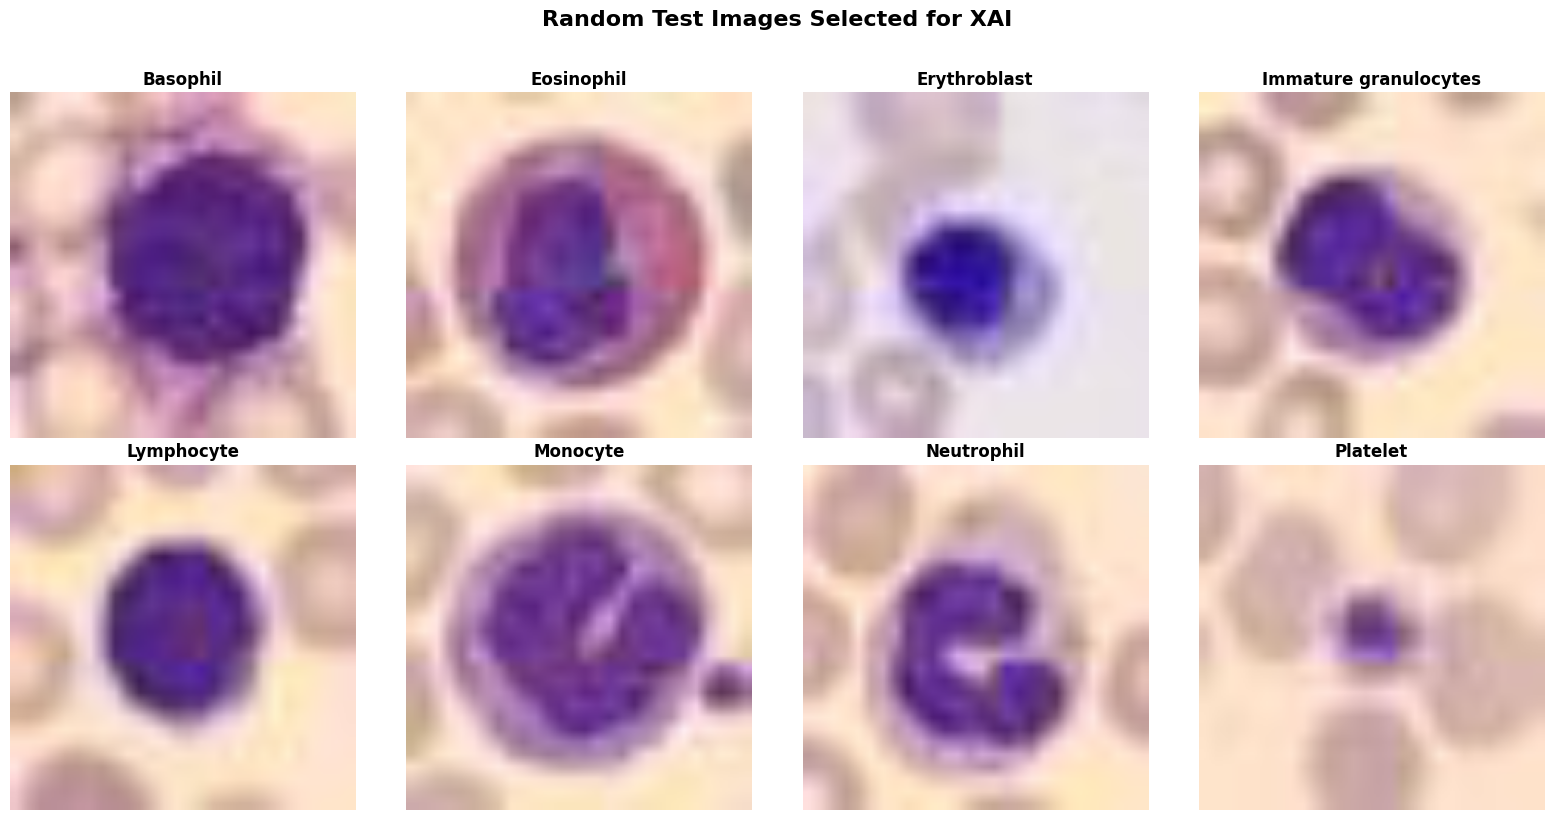

In [45]:
# =========================================================
# Plot the selected XAI images
# =========================================================
#
# Required variables:
#     class_images
#     cols
#     rows
# =========================================================

import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


# Verify required variables
required_plot_variables = [
    "class_images",
    "cols",
    "rows"
]

missing_plot_variables = [
    variable_name
    for variable_name in required_plot_variables
    if variable_name not in globals()
]

if missing_plot_variables:
    raise RuntimeError(
        "Missing required variables: "
        f"{missing_plot_variables}"
    )


# Ensure the grid has enough positions
number_of_images = len(class_images)

if rows * cols < number_of_images:
    raise ValueError(
        f"The {rows} × {cols} grid contains only "
        f"{rows * cols} positions, but class_images "
        f"contains {number_of_images} images."
    )


# Create the figure
figure, axes = plt.subplots(
    rows,
    cols,
    figsize=(4 * cols, 4 * rows)
)

# Convert axes into a one-dimensional array.
# This also works when rows = 1 or cols = 1.
axes = np.asarray(axes).reshape(-1)


# Plot every selected class image
for plot_index, (class_name, image_path) in enumerate(
    class_images.items()
):

    image_path = Path(image_path)

    if not image_path.is_file():
        raise FileNotFoundError(
            f"Image file not found for {class_name}: "
            f"{image_path}"
        )

    with Image.open(image_path) as loaded_image:
        image = loaded_image.convert("RGB")

        axes[plot_index].imshow(image)

    axes[plot_index].set_title(
        class_name,
        fontsize=12,
        fontweight="bold"
    )

    axes[plot_index].axis("off")


# Hide any unused grid positions
for unused_index in range(
    number_of_images,
    len(axes)
):
    axes[unused_index].axis("off")


figure.suptitle(
    "Random Test Images Selected for XAI",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

#Custom Model: CNN with Attention

In [46]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# =========================================================
# Attention Block
# =========================================================

def attention_block(x, reduction=8):
    channels = x.shape[-1]

    # --- channel attention (avg + max) ---
    shared_1 = layers.Dense(max(channels // reduction, 8), activation="relu")
    shared_2 = layers.Dense(channels)

    avg = shared_2(shared_1(layers.GlobalAveragePooling2D()(x)))
    mx = shared_2(shared_1(layers.GlobalMaxPooling2D()(x)))

    w = layers.Activation("sigmoid")(layers.Add()([avg, mx]))
    w = layers.Reshape((1, 1, channels))(w)
    x = layers.Multiply()([x, w])

    # --- spatial attention ---
    s = layers.Conv2D(1, 7, padding="same", activation="sigmoid")(x)
    return layers.Multiply()([x, s])


# =========================================================
# Multiple Conv2D Block
# =========================================================

def conv_block(x, filters, pool=True):
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = attention_block(x)

    if pool:
        x = layers.MaxPooling2D(pool_size=2)(x)

    return x


# =========================================================
# Input Block
# =========================================================

inputs = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

x = layers.Rescaling(1.0 / 127.5, offset=-1.0)(inputs)


# =========================================================
# Feature Extraction Blocks   (28 -> 14 -> 7 -> 7 -> 7)
# =========================================================

x = conv_block(x, 32, pool=True)
x = conv_block(x, 64, pool=True)
x = conv_block(x, 128, pool=False)
x = conv_block(x, 192, pool=False)


# =========================================================
# Classification Block
# =========================================================

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


# =========================================================
# Final Model
# =========================================================

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="BloodNet"
)

In [47]:
model_name = 'BloodNet'

In [48]:
from tensorflow.keras.optimizers import Adam

# Compile the model:
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [49]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

# Record training start time
training_start_time = time.perf_counter()

# train the model (replace this with your model)
history = model.fit(train_dataset, validation_data=val_dataset, epochs=30, callbacks=[early_stopping])

# Record training end time
training_end_time = time.perf_counter()

# Calculate total training time in minutes
total_training_minutes = (training_end_time - training_start_time) / 60


print(f"\nTotal training time: {total_training_minutes:.2f} minutes")


Epoch 1/30


2026-08-14 09:22:20.731031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:22:20.871058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:22:21.823799: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:22:21.978841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:22:25.172747: E external/local_xla/xla/stream_

256/257 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6456 - loss: 1.0051

2026-08-14 09:24:14.618046: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:24:14.754747: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:24:15.343290: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:24:15.493338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 09:24:16.951139: E external/local_xla/xla/stream_

257/257 ━━━━━━━━━━━━━━━━━━━━ 169s 454ms/step - accuracy: 0.7447 - loss: 0.7307 - val_accuracy: 0.2523 - val_loss: 5.4255
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 318ms/step - accuracy: 0.8427 - loss: 0.4504 - val_accuracy: 0.4474 - val_loss: 3.7402
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 317ms/step - accuracy: 0.8827 - loss: 0.3462 - val_accuracy: 0.8043 - val_loss: 0.5788
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 81s 314ms/step - accuracy: 0.9000 - loss: 0.2986 - val_accuracy: 0.4959 - val_loss: 1.8545
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 81s 314ms/step - accuracy: 0.9047 - loss: 0.2759 - val_accuracy: 0.8382 - val_loss: 0.4608
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 81s 316ms/step - accuracy: 0.9063 - loss: 0.2612 - val_accuracy: 0.7611 - val_loss: 0.8333
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 319ms/step - accuracy: 0.9173 - loss: 0.2405 - val_accuracy: 0.8563 - val_loss: 0.4676
Epoch 8/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 318ms/step - accuracy: 0.9252 - loss: 0.2203 - va

###Evaluation

In [50]:
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, cohen_kappa_score, matthews_corrcoef
)

# 1. Evaluate model
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

# 2. True labels
test_true_labels = np.concatenate([labels.numpy().ravel() for _, labels in test_dataset]).astype(np.int32)

# 3. Predictions
test_pred_probs = model.predict(test_dataset, verbose=1)
test_pred_labels = np.argmax(test_pred_probs, axis=1)

# 4. Metrics
precision = precision_score(test_true_labels, test_pred_labels, average="macro", zero_division=0)
recall = recall_score(test_true_labels, test_pred_labels, average="macro", zero_division=0)
f1 = f1_score(test_true_labels, test_pred_labels, average="macro", zero_division=0)
cm = confusion_matrix(test_true_labels, test_pred_labels, labels=np.arange(NUM_CLASSES))

# Specificity
specificity_scores = []
for i in range(NUM_CLASSES):
    tp, fn = cm[i, i], cm[i, :].sum() - cm[i, i]
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
avg_specificity = np.mean(specificity_scores)

# Cohen’s Kappa & MCC
kappa = cohen_kappa_score(test_true_labels, test_pred_labels, labels=np.arange(NUM_CLASSES))
mcc = matthews_corrcoef(test_true_labels, test_pred_labels)

# Results
print(f"\n{model_name} Performance Metrics\n" + "-"*55)
print(f"Test Loss: {test_loss:.2f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Macro Precision: {precision*100:.2f}%")
print(f"Macro Recall: {recall*100:.2f}%")
print(f"Macro F1-Score: {f1*100:.2f}%")
print(f"Average Specificity: {avg_specificity*100:.2f}%")
print(f"Cohen's Kappa: {kappa:.2f}")
print(f"Matthews Corrcoef (MCC): {mcc:.2f}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8115 - loss: 0.7979
107/107 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step

BloodNet Performance Metrics
-------------------------------------------------------
Test Loss: 0.80
Test Accuracy: 81.15%
Macro Precision: 84.53%
Macro Recall: 83.33%
Macro F1-Score: 81.07%
Average Specificity: 97.42%
Cohen's Kappa: 0.78
Matthews Corrcoef (MCC): 0.79


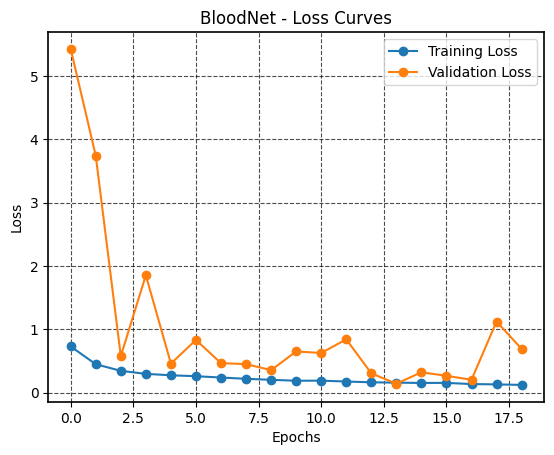

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title(f'{model_name} - Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add grid with black color
plt.grid(True, color='black', linestyle='--', alpha=0.7)

# Ensure borders (spines) are visible and styled
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

plt.show()

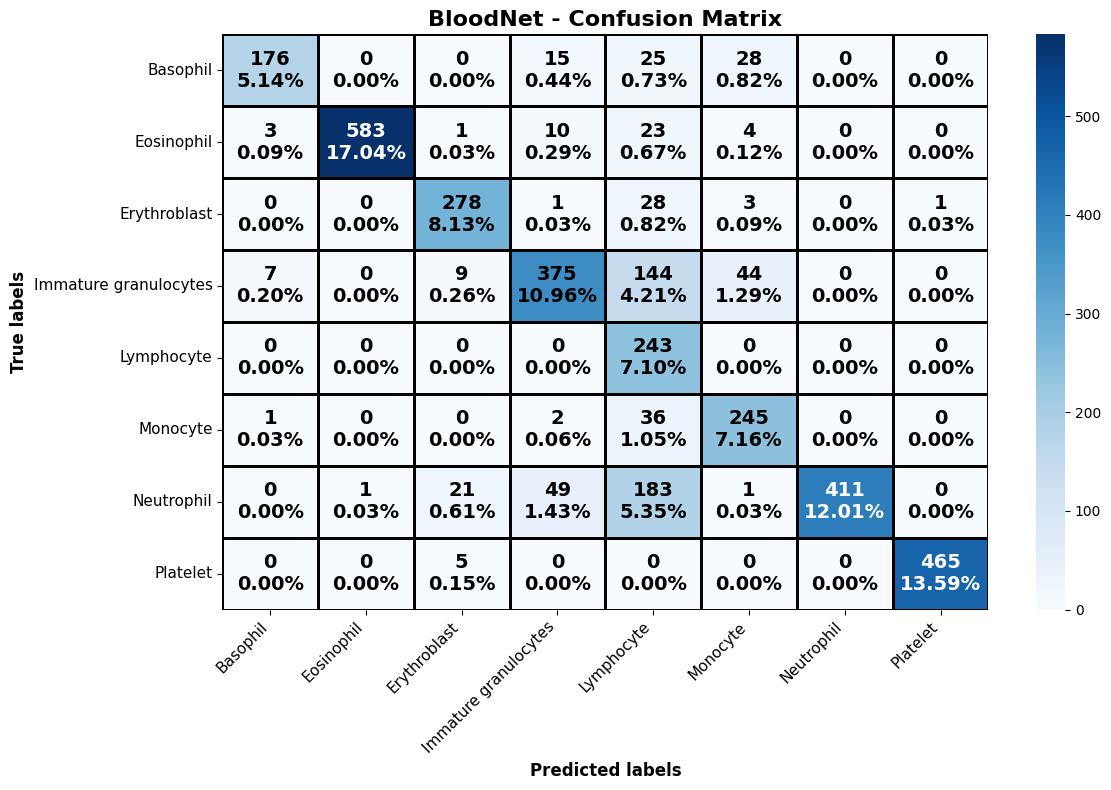

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
conf_matrix = confusion_matrix(test_true_labels, test_pred_labels)

# Global percentages (counts relative to total samples)
conf_percent = conf_matrix.astype('float') / conf_matrix.sum() * 100

# Annotate each cell with "count\nxx.xx%"
annot_text = np.array([
    [f"{conf_matrix[i, j]}\n{conf_percent[i, j]:.2f}%" for j in range(conf_matrix.shape[1])]
    for i in range(conf_matrix.shape[0])
])

# Plot confusion matrix
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    conf_matrix,
    annot=annot_text,
    fmt='',
    cmap='Blues',
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14, "weight": "bold"},
    linecolor='black',
    linewidths=1
)

# Adjust text color dynamically
for text in ax.texts:
    x, y = text.get_position()
    i, j = int(y - 0.5), int(x - 0.5)
    facecolor = ax.collections[0].get_facecolor()[i * conf_matrix.shape[1] + j]
    r, g, b, _ = facecolor
    brightness = (r + g + b) / 3
    text.set_color("white" if brightness < 0.5 else "black")

# Labels and title
plt.xlabel('Predicted labels', fontsize=12, fontweight="bold")
plt.ylabel('True labels', fontsize=12, fontweight="bold")
plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


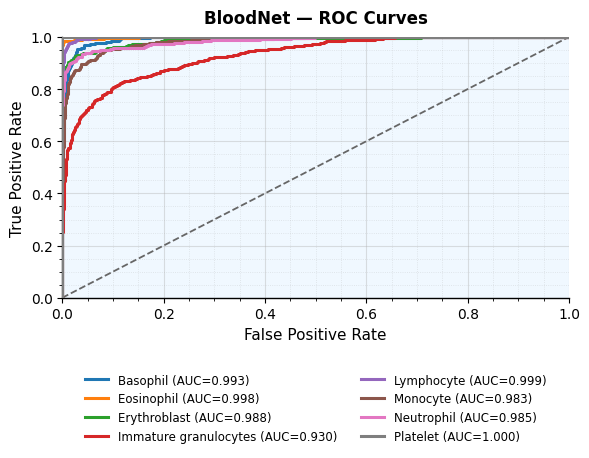

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Interactive mode (works in Jupyter/Notebook; in scripts use plt.show(block=False))
plt.ion()

y_true = np.asarray(test_true_labels)
y_score = np.asarray(test_pred_probs)
class_names = list(class_names)
n_classes = len(class_names)
model_name = str(model_name)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.close("all")
fig, ax = plt.subplots(figsize=(6, 5))

# Light blue background
ax.set_facecolor("aliceblue")

cmap = plt.get_cmap("tab10" if n_classes <= 10 else "tab20")
colors = [cmap(i % cmap.N) for i in range(n_classes)]

# Diagonal reference
ax.plot([0, 1], [0, 1], "--", linewidth=1.3, color="0.4", zorder=1)

# ROC curves
for i, cname in enumerate(class_names):
    ax.plot(fpr[i], tpr[i],
            linewidth=2.2,
            color=colors[i],
            label=f"{cname} (AUC={roc_auc[i]:.3f})",
            zorder=3)

# Axis limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Labels
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{model_name} — ROC Curves",
             fontsize=12, fontweight="bold", pad=10)

# ---- Structured Grid ----
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_xticks(np.arange(0, 1.01, 0.05), minor=True)
ax.set_yticks(np.arange(0, 1.01, 0.05), minor=True)

ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.4)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

# Spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.0)

# Legend outside, bottom center
legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),   # bottom center outside
    frameon=False,
    fontsize=8.5,
    ncol=2
)

plt.tight_layout()
plt.show()


###Model Info

In [54]:
model.save(f'{model_name}.h5')

In [55]:
model.summary()

Model: "BloodNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ re_lu_1[0][0]     │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ re_lu_1[0][0],    │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      1,569 │ multiply[0][0]    │
│                     │ 1)                │            │                 

 Total params: 2,709,550 (10.34 MB)

 Trainable params: 902,628 (3.44 MB)

 Non-trainable params: 1,664 (6.50 KB)

 Optimizer params: 1,805,258 (6.89 MB)

###XAI

In [56]:
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D

# Find the last convolutional layer in the full model
for layer in reversed(model.layers):  # Start from the end
    if isinstance(layer, Conv2D):  # Check if the layer is a convolutional layer
        print(f"Last Conv Layer: {layer.name}, Output Shape: {layer.output.shape}")
        break

# --- Use Grad-CAM for each class image ---
last_conv_layer_name = layer.name  # replace with printed layer name

Last Conv Layer: conv2d_11, Output Shape: (None, 56, 56, 1)


####Grad-CAM

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


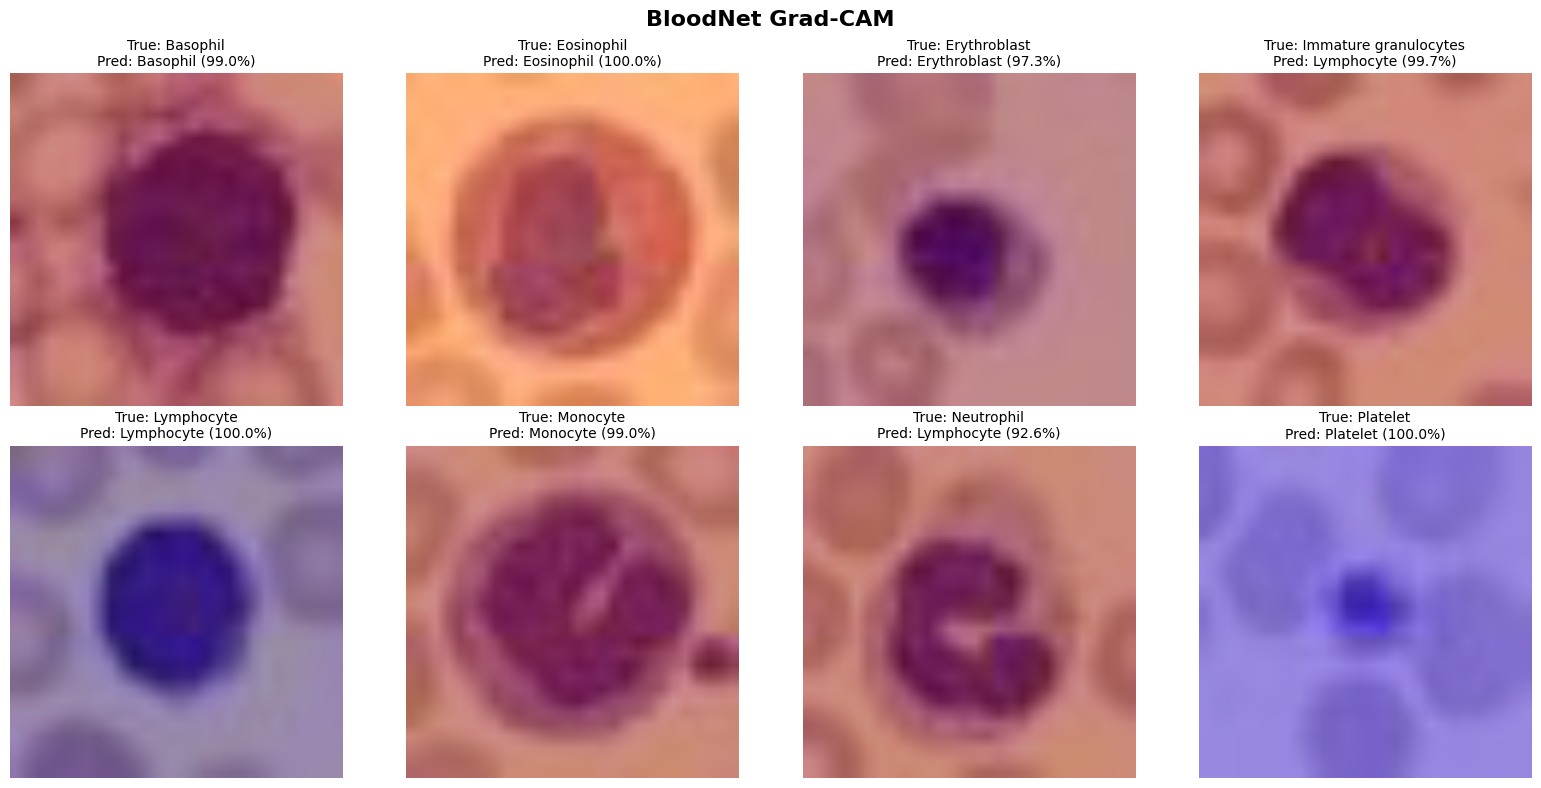

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image


def gradcam(img_path, model, last_conv_layer_name, size=(224, 224)):
    # Load image
    img = image.load_img(img_path, target_size=size, color_mode="rgb")
    img_array = np.expand_dims(image.img_to_array(img), axis=0)

    # Model returning convolution output and predictions
    grad_model = Model(
        model.inputs,
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Calculate gradients
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array, training=False)
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    gradients = tape.gradient(class_score, conv_output)
    weights = tf.reduce_mean(gradients, axis=(0, 1, 2))

    # Create heatmap
    heatmap = tf.reduce_sum(conv_output[0] * weights, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

    # Original image in [0, 1]
    original = image.img_to_array(
        image.load_img(img_path, color_mode="rgb")
    ) / 255.0

    # Resize and color heatmap
    heatmap = tf.image.resize(
        heatmap[..., None],
        original.shape[:2]
    ).numpy().squeeze()

    colored_heatmap = mpl.colormaps["jet"](
        np.clip(heatmap, 0, 1)
    )[..., :3]

    # Blend and clip
    overlay = np.clip(
        0.6 * original + 0.4 * colored_heatmap,
        0,
        1
    )

    return (
        overlay,
        int(predicted_class.numpy()),
        float(tf.reduce_max(predictions[0]).numpy())
    )


# Ensure the grid is large enough
if rows * cols < len(class_images):
    raise ValueError("rows × cols is smaller than the number of class images.")


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4 * cols, 4 * rows)
)

axes = np.asarray(axes).reshape(-1)


for i, (true_class, img_path) in enumerate(class_images.items()):
    overlay, pred_id, confidence = gradcam(
        img_path,
        model,
        last_conv_layer_name,
        size=(IMG_HEIGHT, IMG_WIDTH)
    )

    axes[i].imshow(overlay)
    axes[i].set_title(
        f"True: {true_class}\n"
        f"Pred: {class_names[pred_id]} ({confidence:.1%})",
        fontsize=10
    )
    axes[i].axis("off")


# Hide unused axes
for i in range(len(class_images), len(axes)):
    axes[i].axis("off")


plt.suptitle(
    f"{model_name} Grad-CAM",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

####Lime

LIME inference device: /CPU:0
Generating CPU LIME explanation: Basophil


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating CPU LIME explanation: Eosinophil


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating CPU LIME explanation: Erythroblast


...

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating CPU LIME explanation: Neutrophil


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating CPU LIME explanation: Platelet


  0%|          | 0/1000 [00:00<?, ?it/s]

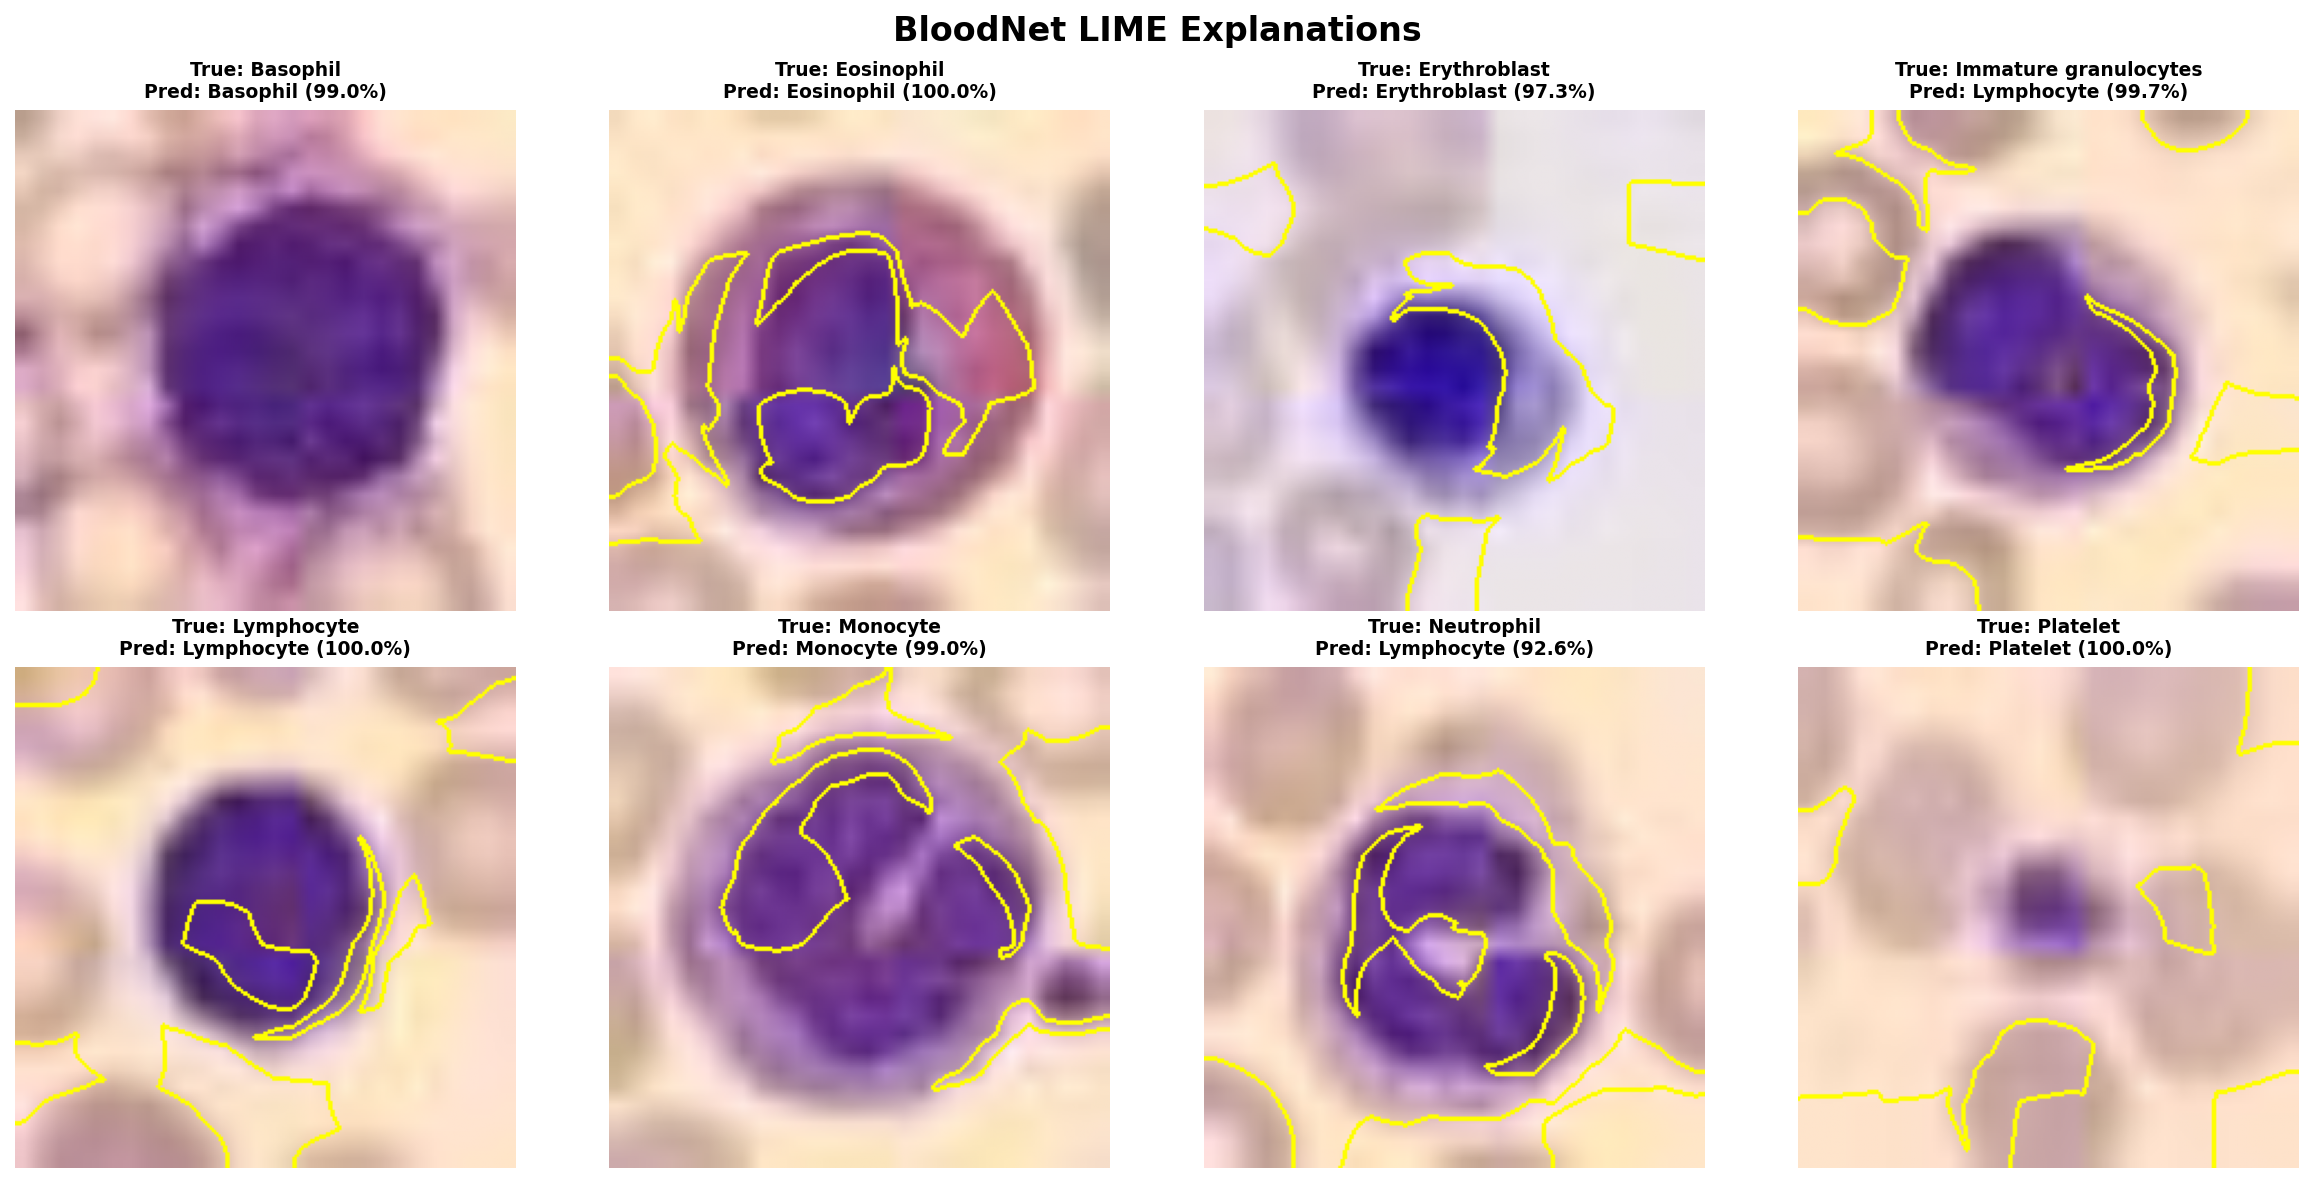

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.segmentation import slic


# =========================================================
# Settings
# =========================================================

input_size = (224, 224)
num_samples = 1000
batch_size = 64
num_features_vis = 8
positive_only = True
hide_color = 0


# =========================================================
# CPU configuration
# =========================================================

LIME_DEVICE = "/CPU:0"

print("LIME inference device:", LIME_DEVICE)


# =========================================================
# Helpers
# =========================================================

def load_rgb(path):
    image_bgr = cv2.imread(path)

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not load image: {path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    return cv2.resize(
        image_rgb,
        input_size,
        interpolation=cv2.INTER_AREA
    )


def predict_fn(images):
    """
    LIME passes batches of RGB images with values near 0–255.

    All model inference performed for LIME is explicitly
    placed on the CPU.
    """
    images = np.asarray(
        images,
        dtype=np.float32
    )

    with tf.device(LIME_DEVICE):
        images = tf.convert_to_tensor(
            images,
            dtype=tf.float32
        )

        predictions = model(
            images,
            training=False
        )

    return predictions.numpy()


def create_lime_overlay(explainer, rgb_image):
    prediction = predict_fn(
        rgb_image[np.newaxis, ...]
    )[0]

    predicted_index = int(
        np.argmax(prediction)
    )

    explanation = explainer.explain_instance(
        image=rgb_image.astype(np.double),
        classifier_fn=predict_fn,
        top_labels=1,
        labels=(predicted_index,),
        hide_color=hide_color,
        num_samples=num_samples,
        batch_size=batch_size,
        segmentation_fn=lambda image: slic(
            image,
            n_segments=50,
            compactness=10,
            sigma=1,
            start_label=0
        ),
        random_seed=42
    )

    explained_image, mask = explanation.get_image_and_mask(
        label=predicted_index,
        positive_only=positive_only,
        num_features=num_features_vis,
        hide_rest=False
    )

    # mark_boundaries expects a float image in [0, 1].
    explained_image = np.clip(
        explained_image / 255.0,
        0.0,
        1.0
    )

    overlay = mark_boundaries(
        explained_image,
        mask,
        color=(1, 1, 0),
        mode="thick"
    )

    return (
        np.clip(overlay, 0.0, 1.0),
        predicted_index,
        float(prediction[predicted_index])
    )


# =========================================================
# Generate LIME explanations
# =========================================================

explainer = lime_image.LimeImageExplainer(
    random_state=42
)

lime_results = []

for true_class, path in class_images.items():
    print(f"Generating CPU LIME explanation: {true_class}")

    rgb_image = load_rgb(path)

    overlay, predicted_index, confidence = (
        create_lime_overlay(
            explainer,
            rgb_image
        )
    )

    predicted_name = class_names[
        predicted_index
    ]

    lime_results.append({
        "image": overlay,
        "true_class": true_class,
        "predicted_class": predicted_name,
        "confidence": confidence
    })


# =========================================================
# Plot explanations
# =========================================================

if rows * cols < len(lime_results):
    raise ValueError(
        f"The {rows} × {cols} grid has only "
        f"{rows * cols} positions for "
        f"{len(lime_results)} images."
    )


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4 * cols, 4 * rows),
    dpi=150
)

axes = np.asarray(axes).reshape(-1)


for index, result in enumerate(lime_results):
    axes[index].imshow(
        result["image"]
    )

    axes[index].set_title(
        f"True: {result['true_class']}\n"
        f"Pred: {result['predicted_class']} "
        f"({result['confidence']:.1%})",
        fontsize=9,
        fontweight="bold"
    )

    axes[index].axis("off")


for index in range(
    len(lime_results),
    len(axes)
):
    axes[index].axis("off")


fig.suptitle(
    f"{model_name} LIME Explanations",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### CNN + Attention Summary

The custom BloodNet model uses convolution blocks with channel and spatial attention. It was evaluated on the BloodMNIST test set using accuracy, macro precision, macro recall, macro F1-score, Cohen's Kappa, MCC, confusion matrix, ROC curve, Grad-CAM, and LIME.

In [59]:
# Save CNN + Attention results before starting the GCN section

cnn_attention_results = {
    "Model": "BloodNet CNN + Attention",
    "Accuracy": test_accuracy,
    "Macro Precision": precision,
    "Macro Recall": recall,
    "Macro F1": f1,
    "Cohen Kappa": kappa,
    "MCC": mcc
}

cnn_attention_pred_probs = test_pred_probs.copy()
cnn_attention_pred_labels = test_pred_labels.copy()

cnn_attention_results

{'Model': 'BloodNet CNN + Attention',
 'Accuracy': 0.8114586472511292,
 'Macro Precision': 0.8453082118035227,
 'Macro Recall': 0.8332900364763818,
 'Macro F1': 0.8107262813733809,
 'Cohen Kappa': np.float64(0.7833122509406061),
 'MCC': np.float64(0.7942509945116659)}

# GCN

In [107]:
# GCN Code Cell 1: Setup for reproducible high-accuracy GCN pipeline

import random
import numpy as np
import pandas as pd
import tensorflow as tf
import time

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef
)

from sklearn.utils.class_weight import compute_class_weight

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Graph configuration
GRAPH_GRID_SIZE = 7
NUM_NODES = GRAPH_GRID_SIZE * GRAPH_GRID_SIZE

y_train_gcn = y_train_prepared.reshape(-1).astype(np.int32)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train_gcn
)

gcn_class_weights = {
    i: float(class_weights_array[i])
    for i in range(NUM_CLASSES)
}

print("GCN pipeline: ResNet50 + Attention + Residual GCN")
print("Seed:", SEED)
print("Graph grid:", GRAPH_GRID_SIZE, "x", GRAPH_GRID_SIZE)
print("Number of graph nodes:", NUM_NODES)
print("Class weights:", gcn_class_weights)

GCN pipeline: ResNet50 + Attention + Residual GCN
Seed: 42
Graph grid: 7 x 7
Number of graph nodes: 49
Class weights: {0: 1.2040786384976525, 1: 0.9267163504968383, 2: 0.9455069124423963, 3: 0.9267163504968383, 4: 1.2083333333333333, 5: 1.0331067472306144, 6: 0.9267163504968383, 7: 0.9267163504968383}


In [108]:
# GCN Code Cell 2: Build normalized grid adjacency matrix for image-to-graph conversion

def build_grid_adjacency(grid_size=GRAPH_GRID_SIZE):
    num_nodes = grid_size * grid_size
    adjacency = np.zeros((num_nodes, num_nodes), dtype=np.float32)

    def node_id(row, col):
        return row * grid_size + col

    for row in range(grid_size):
        for col in range(grid_size):
            current = node_id(row, col)

            neighbors = [
                (row - 1, col),
                (row + 1, col),
                (row, col - 1),
                (row, col + 1)
            ]

            for nr, nc in neighbors:
                if 0 <= nr < grid_size and 0 <= nc < grid_size:
                    neighbor = node_id(nr, nc)
                    adjacency[current, neighbor] = 1.0
                    adjacency[neighbor, current] = 1.0

    # Add self-loops
    adjacency += np.eye(num_nodes, dtype=np.float32)

    # Symmetric normalization: D^(-1/2) A D^(-1/2)
    degree = np.sum(adjacency, axis=1)
    degree_inv_sqrt = np.diag(1.0 / np.sqrt(degree))

    normalized_adjacency = degree_inv_sqrt @ adjacency @ degree_inv_sqrt

    return normalized_adjacency.astype(np.float32)


A_hat_gcn = build_grid_adjacency()

print("Adjacency matrix shape:", A_hat_gcn.shape)
print("Number of nodes:", A_hat_gcn.shape[0])
print("Non-zero adjacency entries:", np.count_nonzero(A_hat_gcn))

Adjacency matrix shape: (49, 49)
Number of nodes: 49
Non-zero adjacency entries: 217


In [109]:
# GCN Code Cell 3: Define attention block and residual GCN layer

class FixedAdjacencyResidualGCNLayer(layers.Layer):
    def __init__(
        self,
        units,
        adjacency,
        activation="relu",
        dropout_rate=0.0,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.units = units
        self.adjacency_np = np.asarray(adjacency, dtype=np.float32)
        self.activation = tf.keras.activations.get(activation)
        self.dropout_rate = dropout_rate

        self.message_dense = layers.Dense(units, use_bias=False)
        self.self_dense = layers.Dense(units, use_bias=False)
        self.norm = layers.BatchNormalization()
        self.dropout = layers.Dropout(dropout_rate)

    def build(self, input_shape):
        self.adjacency = self.add_weight(
            name="fixed_adjacency",
            shape=self.adjacency_np.shape,
            initializer=tf.keras.initializers.Constant(self.adjacency_np),
            trainable=False
        )
        super().build(input_shape)

    def call(self, node_features, training=False):
        neighbor_features = tf.einsum(
            "ij,bjf->bif",
            self.adjacency,
            node_features
        )

        message_output = self.message_dense(neighbor_features)
        self_output = self.self_dense(node_features)

        output = message_output + self_output
        output = self.norm(output, training=training)

        if self.activation is not None:
            output = self.activation(output)

        output = self.dropout(output, training=training)

        return output


def gcn_attention_block(x, reduction=16):
    channels = x.shape[-1]

    shared_dense_1 = layers.Dense(
        max(channels // reduction, 8),
        activation="relu"
    )

    shared_dense_2 = layers.Dense(channels)

    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    avg_attention = shared_dense_2(shared_dense_1(avg_pool))
    max_attention = shared_dense_2(shared_dense_1(max_pool))

    channel_attention = layers.Activation("sigmoid")(
        layers.Add()([avg_attention, max_attention])
    )

    channel_attention = layers.Reshape((1, 1, channels))(channel_attention)

    x = layers.Multiply()([x, channel_attention])

    spatial_attention = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(x)

    x = layers.Multiply()([x, spatial_attention])

    return x


print("Residual GCN layer and attention block are ready.")

Residual GCN layer and attention block are ready.


In [110]:
# GCN Code Cell 4: Build ResNet50 + Attention + Residual GCN model

resnet_backbone = ResNet50(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

resnet_backbone.trainable = False

gcn_input = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="bloodmnist_image"
)

x = layers.Lambda(
    resnet_preprocess_input,
    name="resnet50_preprocessing"
)(gcn_input)

x = resnet_backbone(
    x,
    training=False
)

# ResNet50 feature map is 7 x 7 x 2048 for 224 x 224 input.
# Each spatial location becomes one graph node.
x = layers.Resizing(
    GRAPH_GRID_SIZE,
    GRAPH_GRID_SIZE,
    name="feature_map_to_graph_grid"
)(x)

x = gcn_attention_block(x)

x = layers.Reshape(
    (NUM_NODES, int(x.shape[-1])),
    name="feature_map_nodes"
)(x)

gcn_1 = FixedAdjacencyResidualGCNLayer(
    256,
    A_hat_gcn,
    dropout_rate=0.20,
    name="residual_gcn_1"
)(x)

gcn_2 = FixedAdjacencyResidualGCNLayer(
    256,
    A_hat_gcn,
    dropout_rate=0.20,
    name="residual_gcn_2"
)(gcn_1)

x = layers.Add(name="gcn_residual_skip")([
    gcn_1,
    gcn_2
])

x = FixedAdjacencyResidualGCNLayer(
    128,
    A_hat_gcn,
    dropout_rate=0.20,
    name="residual_gcn_3"
)(x)

x = layers.GlobalAveragePooling1D(
    name="graph_global_average_pooling"
)(x)

x = layers.Dense(
    256,
    activation="relu",
    name="classification_dense"
)(x)

x = layers.BatchNormalization(
    name="classification_batch_norm"
)(x)

x = layers.Dropout(
    0.35,
    name="classification_dropout"
)(x)

gcn_output = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="bloodmnist_classifier"
)(x)

resnet_attention_gcn_model = Model(
    inputs=gcn_input,
    outputs=gcn_output,
    name="ResNet50_Attention_Residual_GCN_BloodMNIST"
)

resnet_attention_gcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_attention_gcn_model.summary()

Model: "ResNet50_Attention_Residual_GCN_BloodMNIST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ bloodmnist_image    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50_preproces… │ (None, 224, 224,  │          0 │ bloodmnist_image… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ resnet50_preproc… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_map_to_gra… │ (None, 7, 7,      │          0 │ resnet50[0][0]    │
│ (Resizing)          │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ feature_map_to_g… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ feature_map_to_g… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 128)       │    262,272 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 2048)      │    264,192 │ dense_37[0][0],   │
│                     │                   │            │ dense_37[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 2048)      │          0 │ dense_38[0][0],   │
│                     │                   │            │ dense_38[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 2048)      │          0 │ add_15[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 1, 1,      │          0 │ activation_27[0]… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_22         │ (None, 7, 7,      │          0 │ feature_map_to_g… │
│ (Multiply)          │ 2048)             │            │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 7, 7, 1)   │    100,353 │ multiply_22[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_23         │ (None, 7, 7,      │          0 │ multiply_22[0][0… │
│ (Multiply)          │ 2048)             │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_map_nodes   │ (None, 49, 2048)  │          0 │ multiply_23[0][0] │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_gcn_1      │ (None, 49, 256)   │  1,052,001 │ feature_map_node… │
│ (FixedAdjacencyRes… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_gcn_2      │ (None, 49, 256)   │    134,497 │ residual_gcn_1[0… │
│ (FixedAdjacencyRes… │                   │            │                 

 Total params: 25,505,580 (97.30 MB)

 Trainable params: 1,908,873 (7.28 MB)

 Non-trainable params: 23,596,707 (90.01 MB)

In [112]:
# GCN Code Cell 5: Train ResNet50 + Attention + Residual GCN with frozen backbone

gcn_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

gcn_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

gcn_training_start_time = time.perf_counter()

gcn_history = resnet_attention_gcn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=gcn_class_weights,
    callbacks=[
        gcn_early_stopping,
        gcn_reduce_lr
    ],
    verbose=1
)

gcn_training_end_time = time.perf_counter()

gcn_training_minutes = (
    gcn_training_end_time - gcn_training_start_time
) / 60

print(f"\nGCN frozen-backbone training time: {gcn_training_minutes:.2f} minutes")

Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step - accuracy: 0.8908 - loss: 0.3080 - val_accuracy: 0.8832 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.9143 - loss: 0.2441 - val_accuracy: 0.8686 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9346 - loss: 0.1999
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 142ms/step - accuracy: 0.9269 - loss: 0.2110 - val_accuracy: 0.8861 - val_loss: 0.3606 - learning_rate: 0.0010
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step - accuracy: 0.9566 - loss: 0.1225 - val_accuracy: 0.9007 - val_loss: 0.3138 - learning_rate: 5.0000e-04
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.9693 - loss: 0.0996 - val_accuracy: 0.9060 - val_loss: 0.3375 - learning_rate: 5.0000e-04
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy

In [113]:
# GCN Code Cell 6: Normal evaluation of ResNet50 + Attention + Residual GCN

gcn_test_loss, gcn_test_accuracy = resnet_attention_gcn_model.evaluate(
    test_dataset,
    verbose=1
)

gcn_pred_probs = resnet_attention_gcn_model.predict(
    test_dataset,
    verbose=1
)

gcn_pred_labels = np.argmax(
    gcn_pred_probs,
    axis=1
)

y_test_gcn = np.concatenate([
    labels.numpy().ravel() for _, labels in test_dataset
]).astype(np.int32)

gcn_precision = precision_score(
    y_test_gcn,
    gcn_pred_labels,
    average="macro",
    zero_division=0
)

gcn_recall = recall_score(
    y_test_gcn,
    gcn_pred_labels,
    average="macro",
    zero_division=0
)

gcn_f1 = f1_score(
    y_test_gcn,
    gcn_pred_labels,
    average="macro",
    zero_division=0
)

gcn_cm = confusion_matrix(
    y_test_gcn,
    gcn_pred_labels,
    labels=np.arange(NUM_CLASSES)
)

gcn_kappa = cohen_kappa_score(
    y_test_gcn,
    gcn_pred_labels
)

gcn_mcc = matthews_corrcoef(
    y_test_gcn,
    gcn_pred_labels
)

gcn_results = {
    "Model": "ResNet50 + Attention + Residual GCN",
    "Accuracy": gcn_test_accuracy,
    "Macro Precision": gcn_precision,
    "Macro Recall": gcn_recall,
    "Macro F1": gcn_f1,
    "Cohen Kappa": gcn_kappa,
    "MCC": gcn_mcc
}

print(f"GCN Test Loss: {gcn_test_loss:.4f}")
print(f"GCN Test Accuracy: {gcn_test_accuracy * 100:.2f}%")
print(f"GCN Macro Precision: {gcn_precision * 100:.2f}%")
print(f"GCN Macro Recall: {gcn_recall * 100:.2f}%")
print(f"GCN Macro F1-Score: {gcn_f1 * 100:.2f}%")
print(f"GCN Cohen's Kappa: {gcn_kappa:.4f}")
print(f"GCN Matthews Corrcoef (MCC): {gcn_mcc:.4f}")

gcn_results

107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step - accuracy: 0.9190 - loss: 0.2849
107/107 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step
GCN Test Loss: 0.2849
GCN Test Accuracy: 91.90%
GCN Macro Precision: 90.71%
GCN Macro Recall: 91.43%
GCN Macro F1-Score: 91.00%
GCN Cohen's Kappa: 0.9055
GCN Matthews Corrcoef (MCC): 0.9056


{'Model': 'ResNet50 + Attention + Residual GCN',
 'Accuracy': 0.9190295338630676,
 'Macro Precision': 0.9070906079230203,
 'Macro Recall': 0.9142616628499985,
 'Macro F1': 0.9099780089709835,
 'Cohen Kappa': np.float64(0.9055301268850394),
 'MCC': np.float64(0.9056497054900154)}

In [114]:
# GCN Code Cell 7: D4 Test-Time Augmentation only

def get_d4_tta_batches(batch_images):
    flipped = tf.image.flip_left_right(batch_images)

    return [
        batch_images,
        tf.image.rot90(batch_images, k=1),
        tf.image.rot90(batch_images, k=2),
        tf.image.rot90(batch_images, k=3),
        flipped,
        tf.image.rot90(flipped, k=1),
        tf.image.rot90(flipped, k=2),
        tf.image.rot90(flipped, k=3)
    ]


def predict_with_d4_tta(trained_model, dataset):
    all_probs = []
    all_labels = []

    for batch_images, batch_labels in dataset:
        tta_probs = []

        for augmented_images in get_d4_tta_batches(batch_images):
            probs = trained_model(
                augmented_images,
                training=False
            ).numpy()

            tta_probs.append(probs)

        mean_probs = np.mean(tta_probs, axis=0)

        all_probs.append(mean_probs)
        all_labels.append(batch_labels.numpy().ravel())

    all_probs = np.vstack(all_probs)
    all_labels = np.concatenate(all_labels).astype(np.int32)

    return all_probs, all_labels


gcn_d4_tta_probs, y_test_d4_tta = predict_with_d4_tta(
    resnet_attention_gcn_model,
    test_dataset
)

gcn_d4_tta_preds = np.argmax(gcn_d4_tta_probs, axis=1)

gcn_d4_tta_accuracy = accuracy_score(y_test_d4_tta, gcn_d4_tta_preds)
gcn_d4_tta_precision = precision_score(y_test_d4_tta, gcn_d4_tta_preds, average="macro", zero_division=0)
gcn_d4_tta_recall = recall_score(y_test_d4_tta, gcn_d4_tta_preds, average="macro", zero_division=0)
gcn_d4_tta_f1 = f1_score(y_test_d4_tta, gcn_d4_tta_preds, average="macro", zero_division=0)

gcn_d4_tta_results = {
    "Model": "ResNet50 + Attention + Residual GCN + D4 TTA",
    "Accuracy": gcn_d4_tta_accuracy,
    "Macro Precision": gcn_d4_tta_precision,
    "Macro Recall": gcn_d4_tta_recall,
    "Macro F1": gcn_d4_tta_f1,
    "Cohen Kappa": cohen_kappa_score(y_test_d4_tta, gcn_d4_tta_preds),
    "MCC": matthews_corrcoef(y_test_d4_tta, gcn_d4_tta_preds)
}

print(f"D4 TTA Test Accuracy: {gcn_d4_tta_accuracy * 100:.2f}%")
print(f"D4 TTA Macro Precision: {gcn_d4_tta_precision * 100:.2f}%")
print(f"D4 TTA Macro Recall: {gcn_d4_tta_recall * 100:.2f}%")
print(f"D4 TTA Macro F1-Score: {gcn_d4_tta_f1 * 100:.2f}%")

gcn_d4_tta_results

D4 TTA Test Accuracy: 94.74%
D4 TTA Macro Precision: 94.03%
D4 TTA Macro Recall: 94.38%
D4 TTA Macro F1-Score: 94.18%


{'Model': 'ResNet50 + Attention + Residual GCN + D4 TTA',
 'Accuracy': 0.9473838059047063,
 'Macro Precision': 0.9403335182022221,
 'Macro Recall': 0.9437622740930055,
 'Macro F1': 0.9417798188074211,
 'Cohen Kappa': np.float64(0.9385568002359623),
 'MCC': np.float64(0.9385900069370381)}